## GSB 545 Midterm Notebook

**Workflow:**
- Part 1: Exploratory data analysis and data preparation
- Part 2: Baseline models (XGBoost, LGBoost, Random Forest, Extra Trees, Logistic Regression) on full feature set -> determine best single bagging and boosting model -> tune models on full, untouched feature set 
- Part 3: Preprocess data further (feature engineering, drop repetitive variables, feature selection). Run models (logistic regression, best bagging, best boosting) on full engineered feature set. Perform feature selection (feature importance, permutation importance, SHAP for tree models; LASSO for logistic regression) and re-fit models. Tune on full or reduced feature set depending on performance.

## Imports and reading in data

In [100]:
!pip install --upgrade numexpr

  Attempting uninstall: numexpr
    Found existing installation: numexpr 2.10.1
    Uninstalling numexpr-2.10.1:
      Successfully uninstalled numexpr-2.10.1

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [62]:
!pip install --upgrade numba

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 2.2 MB/s  0:00:01a 0:00:010:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 6.6 MB/s  0:00:056.5 MB/s eta 0:00:01:02
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.44.0
    Uninstalling llvmlite-0.44.0:
      Successfully uninstalled llvmlite-0.44.0
  Attempting uninstall: numba━━━━━━━━━━━━━━━━━━━━━━━━━ 0/2 [llvmlite]
    Found existing installation: numba 0.61.0━━━━━ 0/2 [llvmlite]
    Uninstalling numba-0.61.0:━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━ 1/2 [numba]
      Successfully uninstalled numba-0.61.038;5;237m╺━━━━━━━━━━━━━━━━━━━ 1/2 [numba]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [numba]━━━━━ 1/2 [numba]

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [131]:
#imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sweetviz as sv
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
import optuna
from sklearn.inspection import permutation_importance
import shap
from sklearn.metrics import make_scorer
from sklearn.model_selection import cross_val_predict

In [140]:
#read in data
campaign_train = pd.read_csv("/Users/donyabehroozi/Documents/gsb545/GSB-545/Midterm/midterm_train.csv")
campaign_test = pd.read_csv("/Users/donyabehroozi/Documents/gsb545/GSB-545/Midterm/midterm_test.csv")

In [73]:
campaign_train.head()

,id,customer_age,occupation_type,relationship_status,education_background,has_credit_issue,mortgage_status,personal_loan_status,last_contact_month,day_of_week,contact_time_minutes,contact_attempt_count,days_since_prior_contact,prior_contact_count,prior_outcome_status,economic_activity_change,consumer_price_index,consumer_confidence_index,reference_interest_rate,employment_level_index,accepted_offer,is_repeat_customer,recent_contact_flag
0,12556,28,services,married,high.school,no,yes,no,jul,tue,286,1,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,0,0,0
1,35451,27,admin.,married,university.degree,no,yes,yes,jul,fri,178,2,999,0,nonexistent,1.4,93.918,-42.7,4.959,5228.1,0,0,0
2,30592,43,self-employed,married,high.school,unknown,yes,no,apr,wed,345,1,999,0,nonexistent,-1.8,93.075,-47.1,1.498,5099.1,0,0,0
3,17914,43,admin.,single,university.degree,no,yes,no,aug,fri,213,2,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0,0,0
4,3315,41,admin.,married,unknown,no,no,no,sep,wed,845,1,7,3,success,-1.1,94.199,-37.5,0.886,4963.6,1,1,1


In [74]:
campaign_test.head()

,id,customer_age,occupation_type,relationship_status,education_background,has_credit_issue,mortgage_status,personal_loan_status,last_contact_month,day_of_week,contact_time_minutes,contact_attempt_count,days_since_prior_contact,prior_contact_count,prior_outcome_status,economic_activity_change,consumer_price_index,consumer_confidence_index,reference_interest_rate,employment_level_index,is_repeat_customer,recent_contact_flag
0,32884,28,admin.,single,university.degree,no,yes,no,jun,fri,12,14,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,0,0
1,3169,60,admin.,married,university.degree,no,no,no,apr,fri,246,3,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0,0
2,32206,35,unemployed,married,university.degree,no,yes,no,oct,thu,391,2,999,0,nonexistent,-3.4,92.431,-26.9,0.733,5017.5,0,0
3,9403,54,housemaid,single,basic.9y,unknown,no,no,nov,mon,158,1,999,1,failure,-0.1,93.200,-42.0,4.191,5195.8,1,0
4,14020,37,blue-collar,married,basic.4y,no,no,no,may,fri,120,17,999,0,nonexistent,1.1,93.994,-36.4,4.864,5191.0,0,0


## Exploratory data analysis

Basic EDA (missingness, duplicates, data types)

In [20]:
#check for missing values in training data
campaign_train.isna().sum()

id                           0
customer_age                 0
occupation_type              0
relationship_status          0
education_background         0
has_credit_issue             0
mortgage_status              0
personal_loan_status         0
last_contact_month           0
day_of_week                  0
contact_time_minutes         0
contact_attempt_count        0
days_since_prior_contact     0
prior_contact_count          0
prior_outcome_status         0
economic_activity_change     0
consumer_price_index         0
consumer_confidence_index    0
reference_interest_rate      0
employment_level_index       0
accepted_offer               0
is_repeat_customer           0
recent_contact_flag          0
dtype: int64

There are no missing values in the training data set

In [6]:
#check for missing values in test data
campaign_test.isna().sum()

id                           0
customer_age                 0
occupation_type              0
relationship_status          0
education_background         0
has_credit_issue             0
mortgage_status              0
personal_loan_status         0
last_contact_month           0
day_of_week                  0
contact_time_minutes         0
contact_attempt_count        0
days_since_prior_contact     0
prior_contact_count          0
prior_outcome_status         0
economic_activity_change     0
consumer_price_index         0
consumer_confidence_index    0
reference_interest_rate      0
employment_level_index       0
is_repeat_customer           0
recent_contact_flag          0
dtype: int64

There are no missing values in the training data set

In [7]:
#check if there are duplicates
print(campaign_train.duplicated().sum())
print(campaign_test.duplicated().sum())

0
0


There are no duplicates in the training nor test data sets.

In [8]:
#number of rows and columns in train and test data
print(campaign_train.shape)
print(campaign_test.shape)

(32950, 23)
(8238, 22)


The training data is larger than the test data, with 32,950 rows and an additional column for the target variable. The test data consists of 8,238 rows excluding the column with the target variable.

In [9]:
#data types
campaign_train.dtypes

id                             int64
customer_age                   int64
occupation_type                  str
relationship_status              str
education_background             str
has_credit_issue                 str
mortgage_status                  str
personal_loan_status             str
last_contact_month               str
day_of_week                      str
contact_time_minutes           int64
contact_attempt_count          int64
days_since_prior_contact       int64
prior_contact_count            int64
prior_outcome_status             str
economic_activity_change     float64
consumer_price_index         float64
consumer_confidence_index    float64
reference_interest_rate      float64
employment_level_index       float64
accepted_offer                 int64
is_repeat_customer             int64
recent_contact_flag            int64
dtype: object

Explore variables in dataset

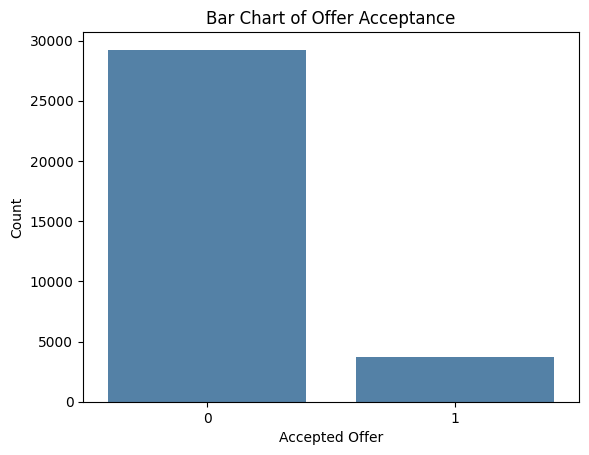

accepted_offer
0    0.887253
1    0.112747
Name: proportion, dtype: float64

In [11]:
#explore target variable (visualization)
sns.countplot(data=campaign_train, x="accepted_offer", color="steelblue")
plt.title("Bar Chart of Offer Acceptance")
plt.xlabel("Accepted Offer")
plt.ylabel("Count")
plt.show()

#explore target variable value counts
campaign_train["accepted_offer"].value_counts(normalize = True)

The target variable (offer acceptance) is imbalanced. Around 88.7% of the training data accounts for individuals who did not accept the offered product, while 11.3% account for individuals who did. This will be an important implication to consider in my modeling process (i.e. baseline models should take into account class imbalance)

In [12]:
#quantitative variable exploration (training data)

#summary statistics
campaign_train.describe()

,id,customer_age,contact_time_minutes,contact_attempt_count,days_since_prior_contact,prior_contact_count,economic_activity_change,consumer_price_index,consumer_confidence_index,reference_interest_rate,employment_level_index,accepted_offer,is_repeat_customer,recent_contact_flag
count,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000
mean,20612.919423,40.016813,257.355387,2.556601,961.748892,0.173445,0.077132,93.574951,-40.508273,3.614729,5166.787681,0.112747,0.136510,0.037511
std,11872.660725,10.421766,256.687433,2.751165,188.697125,0.496422,1.572468,0.579559,4.628221,1.737144,72.459588,0.316288,0.343334,0.190014
min,0.000000,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000,0.000000,0.000000
25%,10373.250000,32.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000,0.000000,0.000000
50%,20610.500000,38.000000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000,0.000000,0.000000
75%,30858.750000,47.000000,318.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000,0.000000,0.000000
max,41187.000000,98.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000,1.000000,1.000000


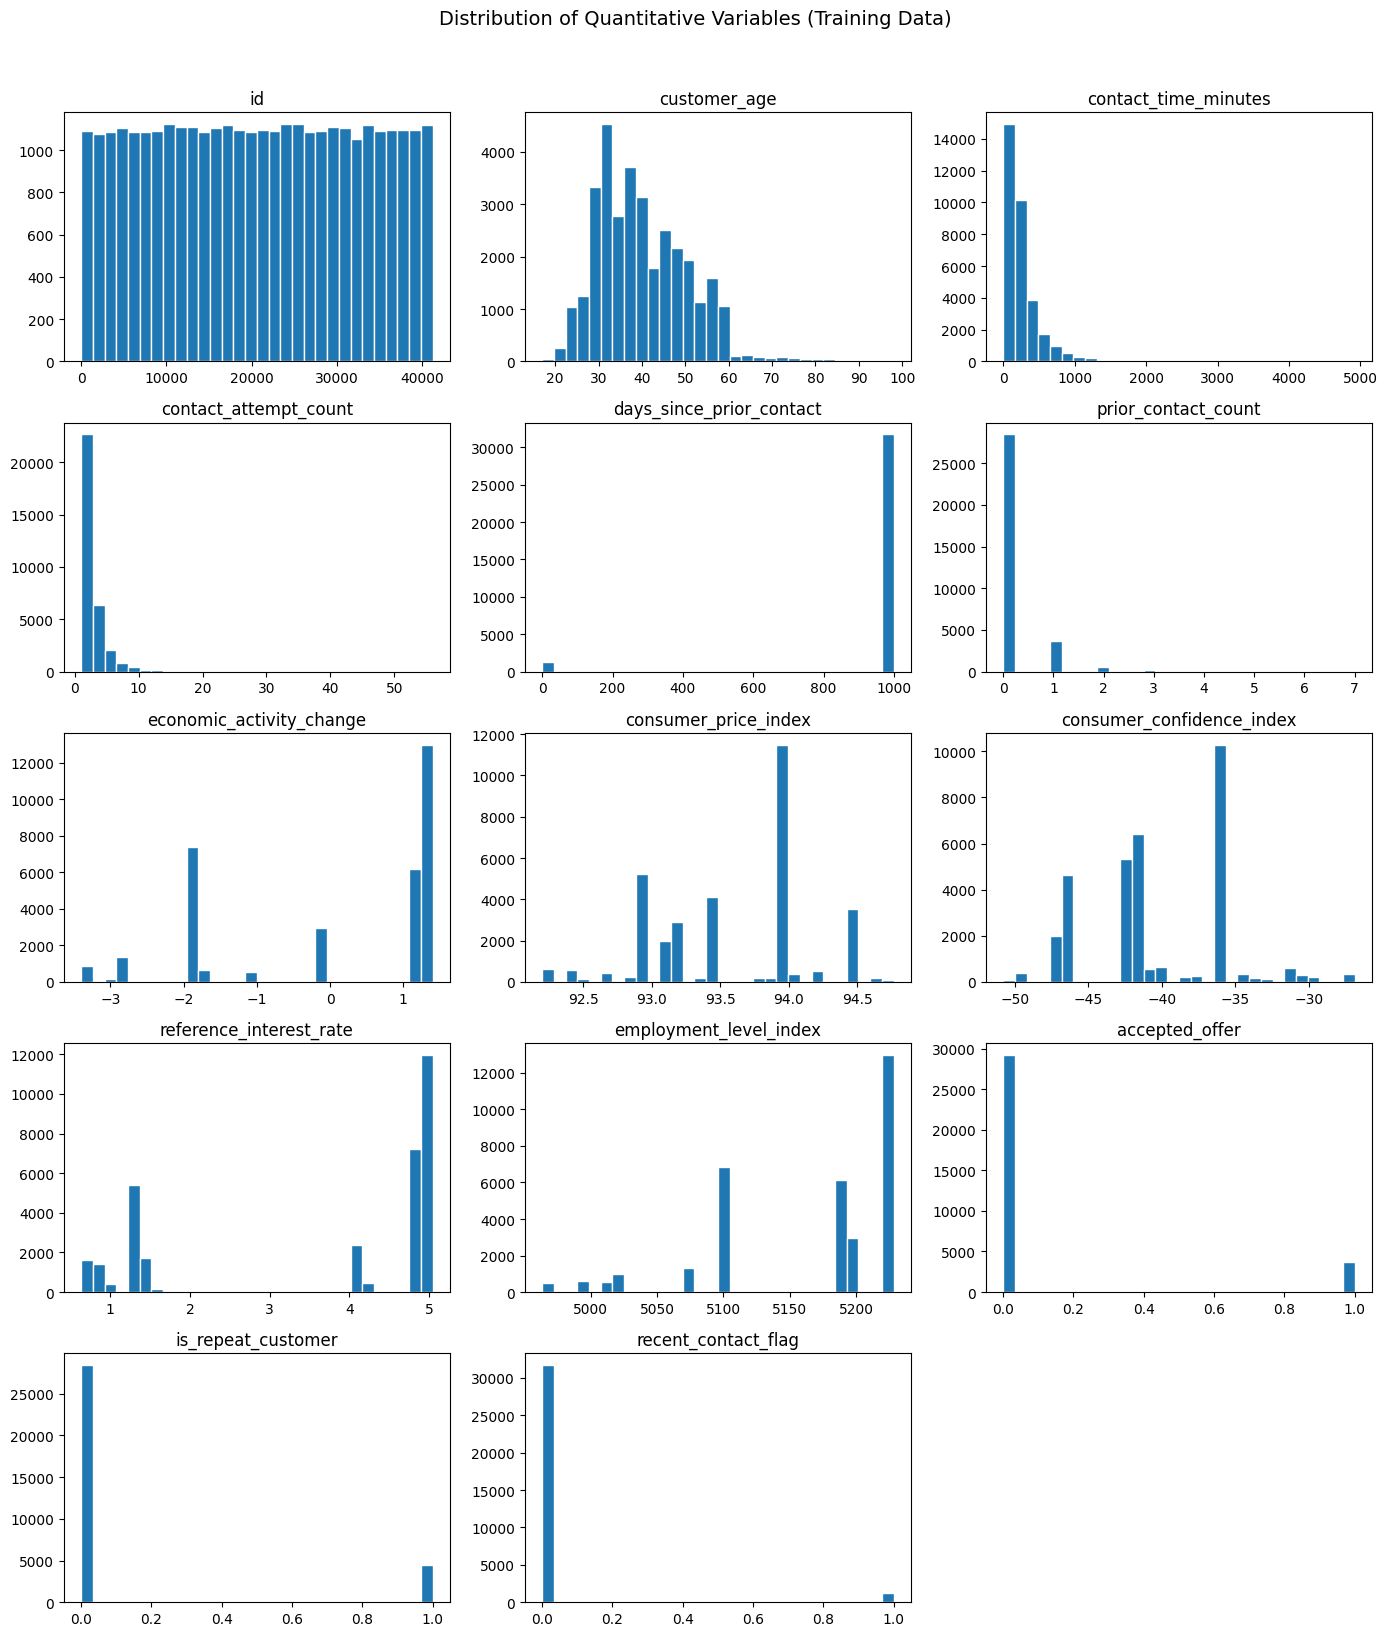

In [13]:
#quantitative variable exploration (training data)

#visualization
quant_vars = campaign_train.select_dtypes(include=['number']).columns.tolist()

fig, axes = plt.subplots(5, 3, figsize=(14, 16))
axes = axes.flatten()
axes[-1].set_visible(False)

for i, var in enumerate(quant_vars):
    axes[i].hist(campaign_train[var], bins=30, edgecolor='white')
    axes[i].set_title(var)
    axes[i].set_xlabel('')

plt.suptitle('Distribution of Quantitative Variables (Training Data)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [14]:
#quantitative variable exploration (test data)

#summary statistics
campaign_test.describe()

,id,customer_age,contact_time_minutes,contact_attempt_count,days_since_prior_contact,prior_contact_count,economic_activity_change,consumer_price_index,consumer_confidence_index,reference_interest_rate,employment_level_index,is_repeat_customer,recent_contact_flag
count,8238.000000,8238.000000,8238.000000,8238.000000,8238.000000,8238.000000,8238.000000,8238.000000,8238.000000,8238.000000,8238.000000,8238.000000,8238.000000
mean,20515.827021,40.053047,262.003277,2.611556,965.381525,0.171037,0.100898,93.578518,-40.479910,3.647536,5168.028769,0.136805,0.033867
std,11959.986153,10.419767,269.380643,2.843901,179.570652,0.488798,1.564865,0.575983,4.628316,1.723473,71.409010,0.343662,0.180899
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000,0.000000
25%,9994.750000,32.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.354000,5099.100000,0.000000,0.000000
50%,20530.000000,38.000000,179.000000,2.000000,999.000000,0.000000,1.100000,93.798000,-41.800000,4.857000,5191.000000,0.000000,0.000000
75%,31024.500000,47.000000,324.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000,0.000000
max,41161.000000,95.000000,4199.000000,40.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000,1.000000


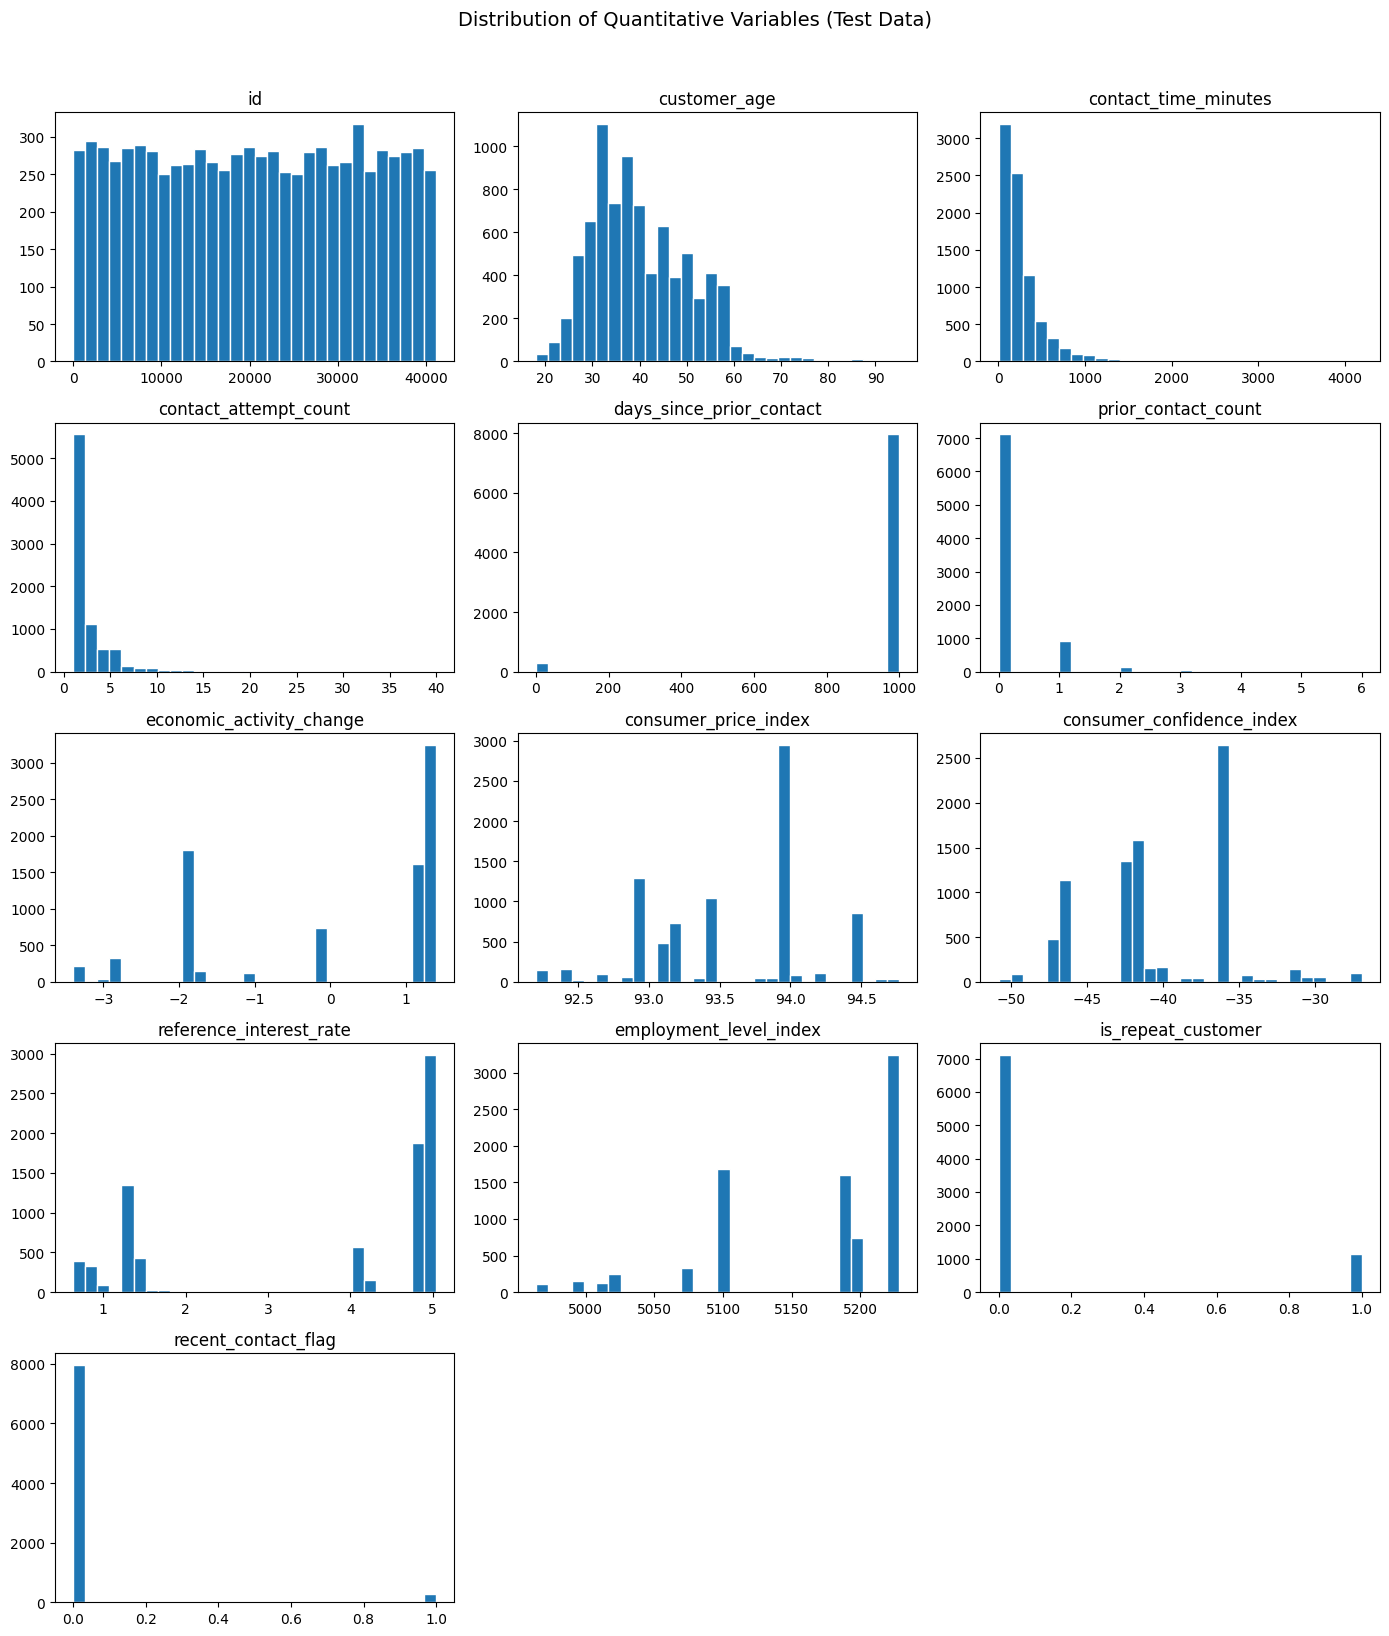

In [15]:
#quantitative variable exploration (test data)
quant_vars = campaign_test.select_dtypes(include=['number']).columns.tolist()

fig, axes = plt.subplots(5, 3, figsize=(14, 16))
axes = axes.flatten()
axes[-1].set_visible(False)
axes[-2].set_visible(False)

for i, var in enumerate(quant_vars):
    axes[i].hist(campaign_test[var], bins=30, edgecolor='white')
    axes[i].set_title(var)
    axes[i].set_xlabel('')

plt.suptitle('Distribution of Quantitative Variables (Test Data)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

There don't appear to be any unusual or missing indicators in the summary statistics of the quantitative variables. There are 14 quantitative variables, two of which include the id of the customer and the target variable in the training data. Customer age, contact time, contact attempt count, and employment level index have skewed distributions. It may be worth exploring transformations of these variables in the feature engineering stage of my workflow. The training and test data distributions for each quantitative variable are very similar

In [16]:
#categorical variable exploration

#unique values for each category
cat_vars = campaign_train.select_dtypes(include=["str"]).columns.tolist()
for column in cat_vars:
    print(column, ":", campaign_train[column].unique())

occupation_type : <ArrowStringArray>
[     'services',        'admin.',
 'self-employed',    'technician',
   'blue-collar',    'management',
       'retired',       'student',
     'housemaid',  'entrepreneur',
    'unemployed',       'unknown']
Length: 12, dtype: str
relationship_status : <ArrowStringArray>
[ 'married',   'single', 'divorced',
  'unknown']
Length: 4, dtype: str
education_background : <ArrowStringArray>
[        'high.school',
   'university.degree',
             'unknown',
            'basic.9y',
            'basic.6y',
 'professional.course',
            'basic.4y',
          'illiterate']
Length: 8, dtype: str
has_credit_issue : <ArrowStringArray>
['no', 'unknown', 'yes']
Length: 3, dtype: str
mortgage_status : <ArrowStringArray>
['yes', 'no', 'unknown']
Length: 3, dtype: str
personal_loan_status : <ArrowStringArray>
['no', 'yes', 'unknown']
Length: 3, dtype: str
last_contact_month : <ArrowStringArray>
['jul', 'apr', 'aug', 'sep', 'may',
 'oct', 'jun', 'nov', 'dec'

In [17]:
#categorical variable exploration

#summary statistics
campaign_train.describe(include=['str'])

,occupation_type,relationship_status,education_background,has_credit_issue,mortgage_status,personal_loan_status,last_contact_month,day_of_week,prior_outcome_status
count,32950,32950,32950,32950,32950,32950,32950,32950,32950
unique,12,4,8,3,3,3,10,5,3
top,admin.,married,university.degree,no,yes,no,may,thu,nonexistent
freq,8336,19889,9772,26089,17291,27168,10980,6893,28452


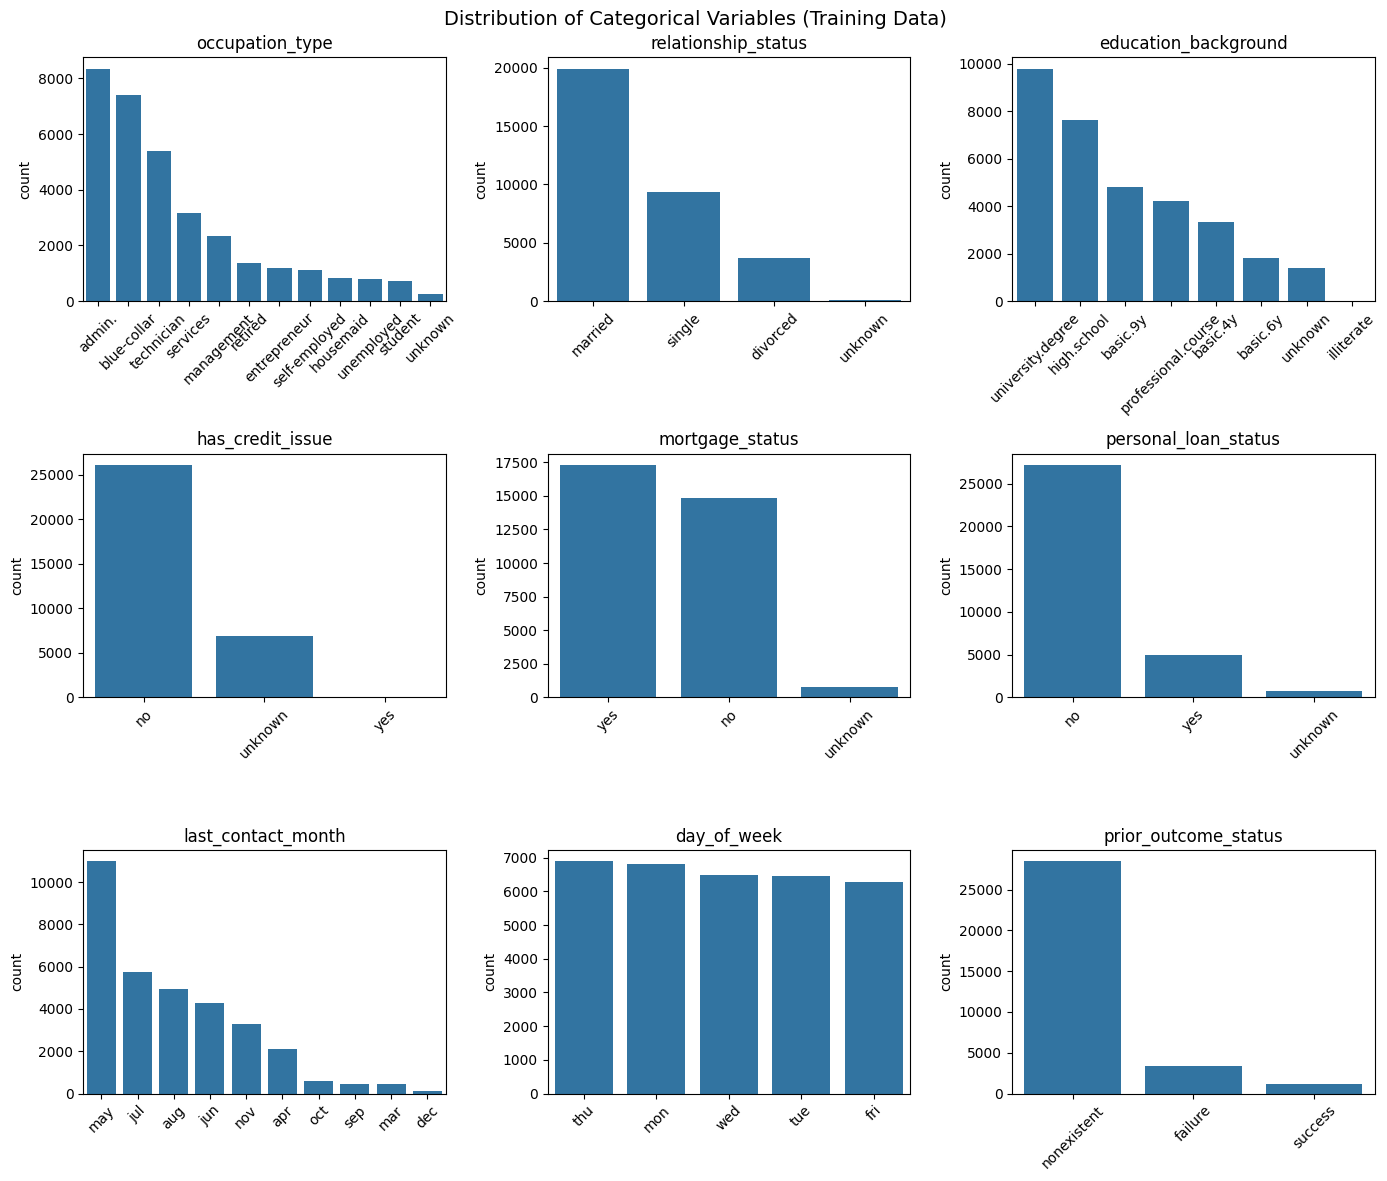

In [18]:
#categorical variable exploration (visualization)
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

for i, var in enumerate(cat_vars):
    order = campaign_train[var].value_counts().index 
    sns.countplot(data=campaign_train, x=var, ax=axes[i], order=order)
    axes[i].set_title(var)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Distribution of Categorical Variables (Training Data)', fontsize=14)
plt.tight_layout()
plt.show()

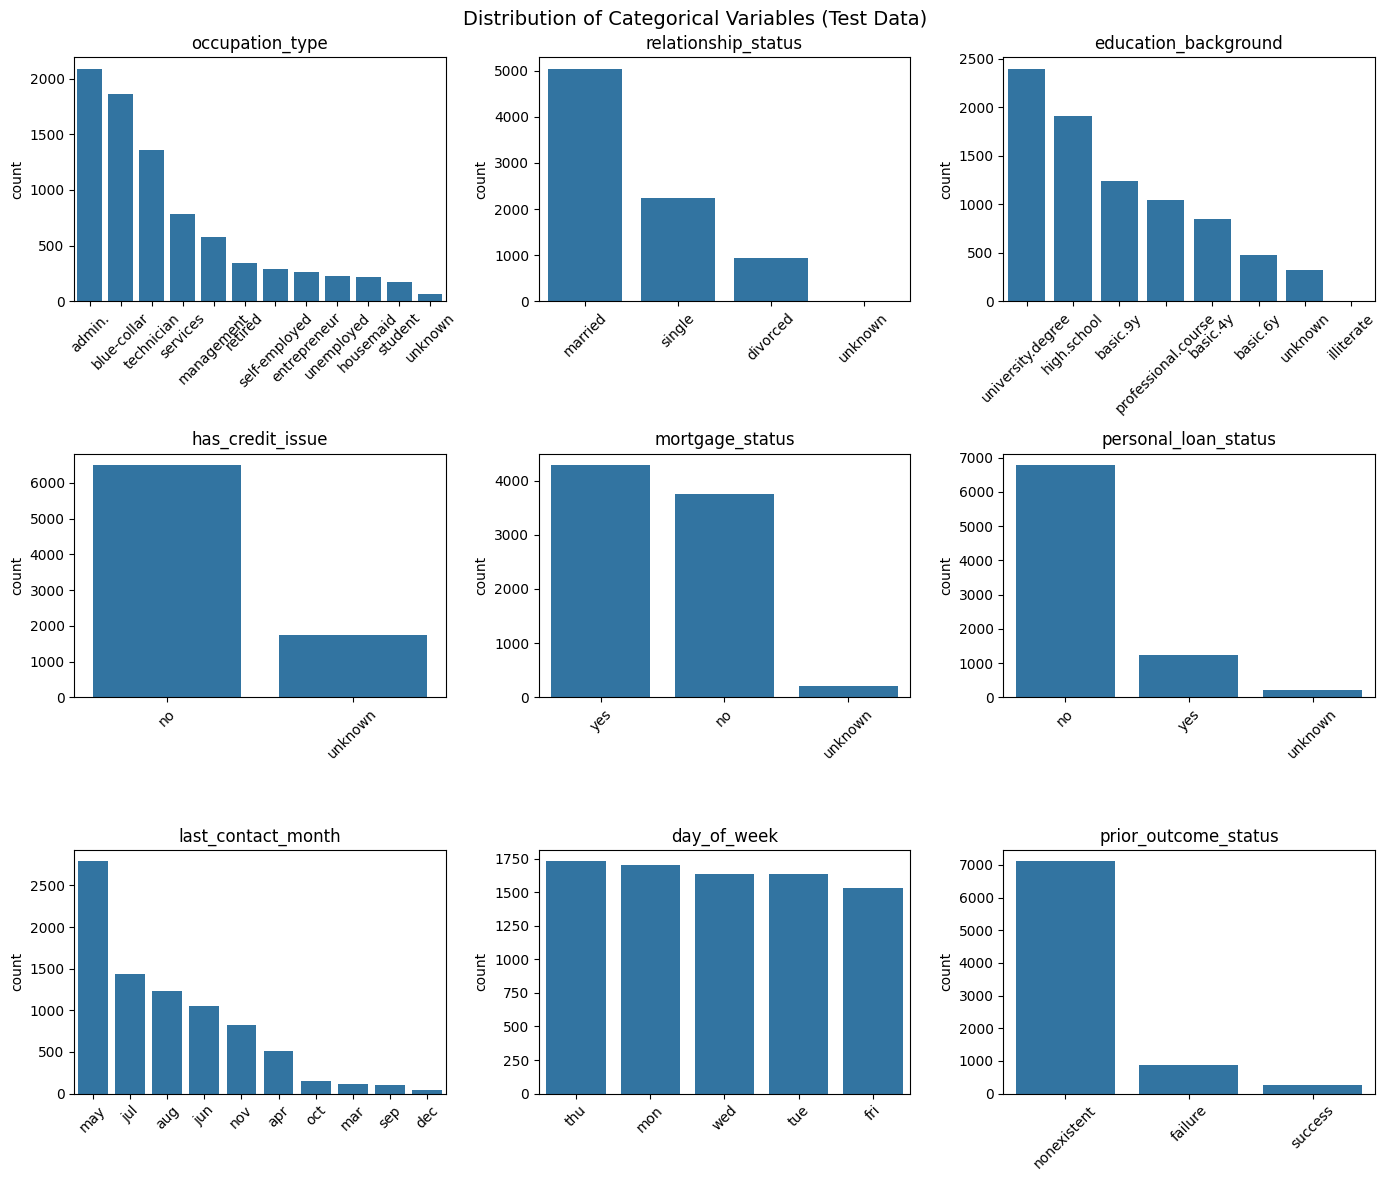

In [19]:
#categorical variable exploration (test data visualization)
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

for i, var in enumerate(cat_vars):
    order = campaign_test[var].value_counts().index 
    sns.countplot(data=campaign_test, x=var, ax=axes[i], order=order)
    axes[i].set_title(var)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Distribution of Categorical Variables (Test Data)', fontsize=14)
plt.tight_layout()
plt.show()

The categorical variable data exploration show several variables with unknown categories. I will likely treat these values as their own category or impute if they become an issue in my modeling. A handful of variables (i.e. occupation type, education background, last contact month) also have rare categories which may be worth grouping to avoid high-cardinality. The distributions of the categorical variables are very similar between the training and test data.

In [20]:
#sweetviz to show visual of associations between variables
midterm_report = sv.analyze(campaign_train)
midterm_report.show_html('midterm_report.html')

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)

Report midterm_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


![Associations between variables](/Users/donyabehroozi/Documents/gsb545/GSB-545/Midterm/midterm_associations.png)


There are a handful of strong, positive associations between many of the variables in this dataset. Associations like days since prior contact and recent contact flag, and prior contact count and days since prior contact make sense, as the two variables in each pair convey the same information. It may be worth exploring dropping a couple of these variables in the feature selection stage. The other strong associations shown in the visual above are not clear to me in terms of their definitions, but are worth exploring in my feature engineering stage. 

## Baseline modeling on untouched, full feature set

In [75]:
# preprocessing steps for baseline models

# define feature lists
cat_vars = campaign_train.select_dtypes(include=['object']).columns.tolist()
for col in cat_vars:
    campaign_train[col] = campaign_train[col].astype('category')

quant_vars = campaign_train.select_dtypes(include=['number']).columns.tolist()
quant_vars = [col for col in quant_vars if col not in ('accepted_offer', 'id')]

# define X and y
X = campaign_train.drop(['accepted_offer', 'id'], axis=1)
y = campaign_train['accepted_offer'] 

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=321, stratify=y
)

# calculate class imbalance ratio using y_train only
neg, pos = np.bincount(y_train) 
scale_pos_weight = neg / pos

# preprocessor for logistic regression
preprocessor_lr = ColumnTransformer(transformers=[
    ('num', StandardScaler(), quant_vars),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_vars)
])

# preprocessor for tree models
preprocessor_tree = ColumnTransformer(transformers=[
    ('num', 'passthrough', quant_vars),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_vars)
])

<positron-console-cell-75>:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.


In [76]:
#define baseline models

#logistic regression
lr_model = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=321
    ))
])

#Random Forest
rf_model = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('classifier', RandomForestClassifier(
        class_weight='balanced',
        random_state=321,
        n_jobs=-1
    ))
])

#Extra Trees
et_model = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('classifier', ExtraTreesClassifier(
        class_weight='balanced',
        random_state=321,
        n_jobs=-1
    ))
])

#XGBoost
xgb_model = XGBClassifier(
        tree_method='hist',     
        enable_categorical=True,  
        scale_pos_weight=scale_pos_weight,
        random_state=321,
        n_jobs=-1,
        eval_metric='logloss'
    )

#LGBoost
lgbm_model = LGBMClassifier(
        is_unbalance=True,        
        random_state=321,
        n_jobs=-1,
        verbose = -1
    )

In [77]:
#define cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=321)

In [78]:
#Logistic regression baseline model results
cv_scores_lr = cross_val_score(lr_model, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
print(cv_scores_lr)
print(cv_scores_lr.mean())
print(cv_scores_lr.std())

lr_model.fit(X_train, y_train)

#evaluate final model performance on held out test set
y_pred = lr_model.predict(X_val)
print("Logistic Regression Baseline F1 Score:", f1_score(y_val, y_pred))
print("Classification Report:")
print(classification_report(y_val, y_pred))

[0.57063093 0.57051282
 0.57142857 0.58140845
 0.55718157]
0.5702324693802626
0.007705796720278158
Logistic Regression Baseline F1 Score: 0.5735882614495331
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.85      0.91      5847
           1       0.43      0.87      0.57       743

    accuracy                           0.85      6590
   macro avg       0.70      0.86      0.74      6590
weighted avg       0.92      0.85      0.87      6590



In [79]:
#Random Forest baseline model results
cv_scores_rf = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
print(cv_scores_rf)
print(cv_scores_rf.mean())
print(cv_scores_rf.std())

rf_model.fit(X_train, y_train)

#evaluate final model performance on held out test set
y_pred = rf_model.predict(X_val)
print("Random Forest Baseline F1 Score:", f1_score(y_val, y_pred))
print("Classification Report:")
print(classification_report(y_val, y_pred))

[0.52095808 0.55186304
 0.51428571 0.53497942
 0.52217742]
0.5288527365260448
0.013312354866933428
Random Forest Baseline F1 Score: 0.5387096774193548
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      5847
           1       0.67      0.45      0.54       743

    accuracy                           0.91      6590
   macro avg       0.80      0.71      0.75      6590
weighted avg       0.90      0.91      0.91      6590



In [80]:
#Extra trees baseline model results
cv_scores_et = cross_val_score(et_model, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
print(cv_scores_et)
print(cv_scores_et.mean())
print(cv_scores_et.std())

et_model.fit(X_train, y_train)

#evaluate final model performance on held out test set
y_pred = et_model.predict(X_val)
print("Extra Trees Baseline F1 Score:", f1_score(y_val, y_pred))
print("Classification Report:")
print(classification_report(y_val, y_pred))

[0.46601942 0.47046187
 0.48884166 0.47497338
 0.46603971]
0.4732672055191075
0.008462997757222368
Extra Trees Baseline F1 Score: 0.46582278481012657
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      5847
           1       0.62      0.37      0.47       743

    accuracy                           0.90      6590
   macro avg       0.77      0.67      0.71      6590
weighted avg       0.89      0.90      0.89      6590



In [81]:
#XGBoost baseline model results
cv_scores_xgb = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
print(cv_scores_xgb)
print(cv_scores_xgb.mean())
print(cv_scores_xgb.std())

xgb_model.fit(X_train, y_train)

#evaluate final model performance on held out test set
y_pred = xgb_model.predict(X_val)
print("XGBoost Baseline F1 Score:", f1_score(y_val, y_pred))
print("Classification Report:")
print(classification_report(y_val, y_pred))

[0.60786974 0.62597403
 0.63460254 0.63171865
 0.59961064]
0.6199551190678882
0.013777581576070985
XGBoost Baseline F1 Score: 0.6358811040339702
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.91      0.94      5847
           1       0.52      0.81      0.64       743

    accuracy                           0.90      6590
   macro avg       0.75      0.86      0.79      6590
weighted avg       0.92      0.90      0.91      6590



In [82]:
#LGBoost baseline model results
cv_scores_lgb = cross_val_score(lgbm_model, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
print(cv_scores_lgb)
print(cv_scores_lgb.mean())
print(cv_scores_lgb.std())

lgbm_model.fit(X_train, y_train)

#evaluate final model performance on held out test set
y_pred = lgbm_model.predict(X_val)
print("LGBoost Baseline F1 Score:", f1_score(y_val, y_pred))
print("Classification Report:")
print(classification_report(y_val, y_pred))

[0.62114014 0.61784897
 0.6274279  0.63379435
 0.6018412 ]
0.6204105111752115
0.01077296705698926
LGBoost Baseline F1 Score: 0.6347138203815729
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.88      0.93      5847
           1       0.49      0.92      0.63       743

    accuracy                           0.88      6590
   macro avg       0.74      0.90      0.78      6590
weighted avg       0.93      0.88      0.90      6590



**Quick insights**

- Both boosting baseline tree models performed the best overall in terms of F1 score on the held out data (0.636 and 0.635 for XGBoost and XGBoost models respectively)
- Extra Trees baseline model performed the worst (F1 score on held out data = 0.466)

## Baseline model tuning on untouched, full feature set

In [35]:
#logistic regression model tuning
def objective_lr(trial):
    params = {
        'classifier__C': trial.suggest_float('C', 1e-4, 10, log=True),
        'classifier__solver': trial.suggest_categorical('solver', ['lbfgs', 'saga']),
        'classifier__max_iter': trial.suggest_int('max_iter', 500, 2000),
    }
    pipeline = Pipeline([
        ('preprocessor', preprocessor_lr),
        ('classifier', LogisticRegression(
            class_weight='balanced',
            random_state=321,
            **{k.split('__')[1]: v for k, v in params.items()} #strips prefix from pipeline
        ))
    ])
    return cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1).mean()

study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=50)
print("Best Linear Regression params:", study_lr.best_params)

best_lr = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        random_state=321,
        C=study_lr.best_params['C'],
        solver=study_lr.best_params['solver'],
        max_iter=study_lr.best_params['max_iter']
    ))
])

best_lr.fit(X_train, y_train)
y_pred_lr = best_lr.predict(X_val)
print("=== Logistic Regression Results ===")
print(f"F1 Score: {f1_score(y_val, y_pred_lr):.4f}")
print(classification_report(y_val, y_pred_lr))

[I 2026-05-07 11:36:29,450] A new study created in memory with name: no-name-de5d4bb9-ba13-4b92-ac96-06ddcee68c3a
[I 2026-05-07 11:36:29,898] Trial 0 finished with value: 0.569703054089201 and parameters: {'C': 0.254449922505022, 'solver': 'saga', 'max_iter': 845}. Best is trial 0 with value: 0.569703054089201.
[I 2026-05-07 11:36:30,393] Trial 1 finished with value: 0.5701644315554228 and parameters: {'C': 0.512932523502861, 'solver': 'saga', 'max_iter': 1739}. Best is trial 1 with value: 0.5701644315554228.
[I 2026-05-07 11:36:30,634] Trial 2 finished with value: 0.5646598080006184 and parameters: {'C': 0.013423846038215266, 'solver': 'saga', 'max_iter': 1710}. Best is trial 1 with value: 0.5701644315554228.
[I 2026-05-07 11:36:30,782] Trial 3 finished with value: 0.569834677061439 and parameters: {'C': 0.24603014330195566, 'solver': 'lbfgs', 'max_iter': 1461}. Best is trial 1 with value: 0.5701644315554228.
[I 2026-05-07 11:36:30,918] Trial 4 finished with value: 0.5517176513256491 

Best Linear Regression params: {'C': 2.3805430322288714, 'solver': 'saga', 'max_iter': 1578}
=== Logistic Regression Results ===
F1 Score: 0.5723
              precision    recall  f1-score   support

           0       0.98      0.85      0.91      5847
           1       0.43      0.87      0.57       743

    accuracy                           0.85      6590
   macro avg       0.70      0.86      0.74      6590
weighted avg       0.92      0.85      0.87      6590



In [36]:
#Random Forest model tuning
def objective_rf(trial):
    clf = RandomForestClassifier(
        n_estimators=trial.suggest_int('n_estimators', 100, 1000),
        max_depth=trial.suggest_int('max_depth', 3, 20),
        min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
        min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10),
        max_features=trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
        class_weight='balanced',
        random_state=321,
        n_jobs=-1
    )
    pipeline = Pipeline([('preprocessor', preprocessor_tree), ('classifier', clf)])
    return cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1).mean()

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=50)

best_rf = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('classifier', RandomForestClassifier(
        class_weight='balanced',
        random_state=321,
        n_jobs=-1,
        **study_rf.best_params
    ))
])
best_rf.fit(X_train, y_train)
y_pred_rf = best_rf.predict(X_val)
print("=== Random Forest Results ===")
print(f"F1 Score: {f1_score(y_val, y_pred_rf):.4f}")
print(classification_report(y_val, y_pred_rf))

[I 2026-05-07 11:39:01,074] A new study created in memory with name: no-name-24c2de96-60c5-4f1c-b4a3-b3b025941321
[I 2026-05-07 11:39:03,395] Trial 0 finished with value: 0.6440166953686325 and parameters: {'n_estimators': 330, 'max_depth': 18, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.6440166953686325.
[I 2026-05-07 11:39:09,089] Trial 1 finished with value: 0.6196250381497279 and parameters: {'n_estimators': 989, 'max_depth': 12, 'min_samples_split': 6, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.6440166953686325.
[I 2026-05-07 11:39:12,366] Trial 2 finished with value: 0.557738346836483 and parameters: {'n_estimators': 749, 'max_depth': 5, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 0 with value: 0.6440166953686325.
[I 2026-05-07 11:39:17,245] Trial 3 finished with value: 0.6352452326377283 and parameters: {'n_estimators': 736, 'max_depth': 13, 'min

=== Random Forest Results ===
F1 Score: 0.6732
              precision    recall  f1-score   support

           0       0.97      0.93      0.95      5847
           1       0.59      0.79      0.67       743

    accuracy                           0.91      6590
   macro avg       0.78      0.86      0.81      6590
weighted avg       0.93      0.91      0.92      6590



In [37]:
#Extra Trees model tuning
def objective_et(trial):
    clf = ExtraTreesClassifier(
        n_estimators=trial.suggest_int('n_estimators', 100, 1000),
        max_depth=trial.suggest_int('max_depth', 3, 20),
        min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
        min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10),
        max_features=trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
        class_weight='balanced',
        random_state=321,
        n_jobs=-1
    )
    pipeline = Pipeline([('preprocessor', preprocessor_tree), ('classifier', clf)])
    return cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1).mean()

study_et = optuna.create_study(direction='maximize')
study_et.optimize(objective_et, n_trials=50)

best_et = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('classifier', ExtraTreesClassifier(
        class_weight='balanced',
        random_state=321,
        n_jobs=-1,
        **study_et.best_params
    ))
])
best_et.fit(X_train, y_train)
y_pred_et = best_et.predict(X_val)
print("=== Extra Trees Results ===")
print(f"F1 Score: {f1_score(y_val, y_pred_et):.4f}")
print(classification_report(y_val, y_pred_et))

[I 2026-05-07 11:44:22,982] A new study created in memory with name: no-name-538c50a7-cbab-4b7d-875a-bfa961e53fd7
[I 2026-05-07 11:44:23,631] Trial 0 finished with value: 0.5295393436507132 and parameters: {'n_estimators': 116, 'max_depth': 10, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 0 with value: 0.5295393436507132.
[I 2026-05-07 11:44:25,532] Trial 1 finished with value: 0.586036094134622 and parameters: {'n_estimators': 256, 'max_depth': 11, 'min_samples_split': 18, 'min_samples_leaf': 4, 'max_features': 0.5}. Best is trial 1 with value: 0.586036094134622.
[I 2026-05-07 11:44:26,289] Trial 2 finished with value: 0.3802894570534491 and parameters: {'n_estimators': 283, 'max_depth': 4, 'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.586036094134622.
[I 2026-05-07 11:44:29,871] Trial 3 finished with value: 0.5449830552027984 and parameters: {'n_estimators': 851, 'max_depth': 11, 'min_sa

=== Extra Trees Results ===
F1 Score: 0.6400
              precision    recall  f1-score   support

           0       0.97      0.92      0.94      5847
           1       0.55      0.77      0.64       743

    accuracy                           0.90      6590
   macro avg       0.76      0.85      0.79      6590
weighted avg       0.92      0.90      0.91      6590



In [38]:
#XGBoost model tuning
def objective_xgb(trial):
    clf = XGBClassifier(
        n_estimators=trial.suggest_int('n_estimators', 100, 1000),
        max_depth=trial.suggest_int('max_depth', 3, 10),
        learning_rate=trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        subsample=trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1.0),
        min_child_weight=trial.suggest_int('min_child_weight', 1, 10),
        gamma=trial.suggest_float('gamma', 0, 5),
        tree_method='hist',
        enable_categorical=True,
        scale_pos_weight=scale_pos_weight,
        random_state=321,
        n_jobs=-1,
        eval_metric='logloss'
    )
    return cross_val_score(clf, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1).mean()

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=50)

best_xgb = XGBClassifier(
    tree_method='hist',
    enable_categorical=True,
    scale_pos_weight=scale_pos_weight,
    random_state=321,
    n_jobs=-1,
    eval_metric='logloss',
    **study_xgb.best_params
)
best_xgb.fit(X_train, y_train)
y_pred_xgb = best_xgb.predict(X_val)
print("=== XGBoost Results ===")
print(f"F1 Score: {f1_score(y_val, y_pred_xgb):.4f}")
print(classification_report(y_val, y_pred_xgb))

[I 2026-05-07 11:49:58,556] A new study created in memory with name: no-name-5ad8c8f8-a28f-4481-a9a8-5f2d7f74f7cc
[I 2026-05-07 11:49:59,094] Trial 0 finished with value: 0.6099401203123069 and parameters: {'n_estimators': 167, 'max_depth': 9, 'learning_rate': 0.005065667786154823, 'subsample': 0.8268053142752664, 'colsample_bytree': 0.5078462685398185, 'min_child_weight': 1, 'gamma': 3.895965729144286}. Best is trial 0 with value: 0.6099401203123069.
[I 2026-05-07 11:49:59,534] Trial 1 finished with value: 0.5623588345803352 and parameters: {'n_estimators': 305, 'max_depth': 4, 'learning_rate': 0.0018011043248555296, 'subsample': 0.8267476520926813, 'colsample_bytree': 0.6076830811383668, 'min_child_weight': 8, 'gamma': 0.9063376137653067}. Best is trial 0 with value: 0.6099401203123069.
[I 2026-05-07 11:50:00,332] Trial 2 finished with value: 0.6201671482406406 and parameters: {'n_estimators': 464, 'max_depth': 6, 'learning_rate': 0.022774691845200784, 'subsample': 0.889182673384457,

=== XGBoost Results ===
F1 Score: 0.6737
              precision    recall  f1-score   support

           0       0.98      0.91      0.94      5847
           1       0.55      0.86      0.67       743

    accuracy                           0.91      6590
   macro avg       0.77      0.89      0.81      6590
weighted avg       0.93      0.91      0.91      6590



In [39]:
#LGBoost model tuning
def objective_lgbm(trial):
    clf = LGBMClassifier(
        n_estimators=trial.suggest_int('n_estimators', 100, 1000),
        max_depth=trial.suggest_int('max_depth', 3, 20),
        learning_rate=trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        num_leaves=trial.suggest_int('num_leaves', 20, 300),
        min_child_samples=trial.suggest_int('min_child_samples', 5, 100),
        subsample=trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha=trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
        reg_lambda=trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
        is_unbalance=True,
        random_state=321,
        n_jobs=-1,
        verbose = -1
    )
    return cross_val_score(clf, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1).mean()

study_lgbm = optuna.create_study(direction='maximize')
study_lgbm.optimize(objective_lgbm, n_trials=50)

best_lgbm = LGBMClassifier(
    is_unbalance=True,
    random_state=321,
    n_jobs=-1,
    verbose = -1,
    **study_lgbm.best_params
)
best_lgbm.fit(X_train, y_train)
y_pred_lgbm = best_lgbm.predict(X_val)
print("=== LightGBM Results ===")
print(f"F1 Score: {f1_score(y_val, y_pred_lgbm):.4f}")
print(classification_report(y_val, y_pred_lgbm))

[I 2026-05-07 12:00:35,954] A new study created in memory with name: no-name-3bae3e89-4b98-49a4-8b12-55aac41cb8a2
[I 2026-05-07 12:01:23,498] Trial 0 finished with value: 0.6410113886759433 and parameters: {'n_estimators': 820, 'max_depth': 15, 'learning_rate': 0.0015387032336301953, 'num_leaves': 104, 'min_child_samples': 49, 'subsample': 0.9750568438165979, 'colsample_bytree': 0.7409536170824123, 'reg_alpha': 1.4707335601203814e-07, 'reg_lambda': 0.052205910367836714}. Best is trial 0 with value: 0.6410113886759433.
[I 2026-05-07 12:01:50,325] Trial 1 finished with value: 0.6241153276171855 and parameters: {'n_estimators': 313, 'max_depth': 16, 'learning_rate': 0.008988366959474747, 'num_leaves': 145, 'min_child_samples': 22, 'subsample': 0.5822701848234961, 'colsample_bytree': 0.5716273967745397, 'reg_alpha': 1.2483141569444634e-08, 'reg_lambda': 2.4829370914228337e-06}. Best is trial 0 with value: 0.6410113886759433.
[I 2026-05-07 12:02:25,457] Trial 2 finished with value: 0.598722

=== LightGBM Results ===
F1 Score: 0.6693
              precision    recall  f1-score   support

           0       0.97      0.93      0.95      5847
           1       0.58      0.80      0.67       743

    accuracy                           0.91      6590
   macro avg       0.77      0.86      0.81      6590
weighted avg       0.93      0.91      0.92      6590



**Quick Insights**

- The logistic regression model is not doing very well. It might be best to use this model as my meta-learner for the ensemble model instead of using it to predict on its own (F1 score on held out dataset = 0.572)
- Random Forest performed much better with tuning (F1 score on held out dataset = 0.673 instead of 0.539 without tuning)
- Extra Trees performed much better (F1 score on held out dataset = 0.64 instead of 0.466 without tuning) but the amount of variation in F1-score between trials makes me a bit worried about its performance on the test set
- XGBoost performed the best in tuning with a F1 score of 0.674 on the held out test set

## Feature engineering

In [83]:
#transformations for skewed distributions
campaign_train['log_contact_time'] = np.log1p(campaign_train['contact_time_minutes'])
campaign_train['log_contact_attempts'] = np.log1p(campaign_train['contact_attempt_count'])

#binning of quantitative data
campaign_train['age_categories'] = pd.cut(
    campaign_train['customer_age'],
    bins=[0, 30, 40, 50, 60, 100],
    labels=['20s', '30s', '40s', '50s', '60+']
)

#binning of categorical data
#group occupation type into broader categories to avoid rare categories
occupation_map = {
    'admin.'        : 'white_collar',
    'management'    : 'white_collar',
    'entrepreneur'  : 'white_collar',
    'self-employed' : 'white_collar',
    'technician'    : 'skilled',
    'services'      : 'skilled',
    'blue-collar'   : 'blue_collar',
    'housemaid'     : 'blue_collar',
    'retired'       : 'inactive',
    'unemployed'    : 'inactive',
    'student'       : 'inactive',
    'unknown'       : 'unknown'
}
campaign_train['occupation_group'] = campaign_train['occupation_type'].map(occupation_map)

#group education background into broader categories
education_map = {
    'university.degree'    : 'higher',
    'professional.course'  : 'higher',
    'high.school'          : 'secondary',
    'basic.9y'             : 'basic',
    'basic.6y'             : 'basic',
    'basic.4y'             : 'basic',
    'illiterate'           : 'basic',
    'unknown'              : 'unknown'
}
campaign_train['education_level'] = campaign_train['education_background'].map(education_map)

#group last contact month into quarters
month_quarter_map = {
    'jan': 'Q1', 'feb': 'Q1', 'mar': 'Q1',
    'apr': 'Q2', 'may': 'Q2', 'jun': 'Q2',
    'jul': 'Q3', 'aug': 'Q3', 'sep': 'Q3',
    'oct': 'Q4', 'nov': 'Q4', 'dec': 'Q4'
}
campaign_train['contact_quarter'] = campaign_train['last_contact_month'].map(month_quarter_map)


#interactions between features
#strong correlation between reference_interest_rate and employment_level_index
campaign_train['econ_stress_index'] = (campaign_train['reference_interest_rate'] * campaign_train['employment_level_index'])

#contact_time_minutes * contact_attempt_count = total engagement effort
campaign_train['total_contact_effort'] = (campaign_train['contact_time_minutes'] * campaign_train['contact_attempt_count'])

#age and education interaction
campaign_train['age_x_education'] = (
    campaign_train['customer_age'] * 
    campaign_train['education_level'].map({ 
        'higher': 3, 'secondary': 2, 'basic': 1, 'unknown': 0
    })
)

#polynomial features
campaign_train['customer_age_sq'] = campaign_train['customer_age'] ** 2

campaign_train['interest_rate_sq'] = campaign_train['reference_interest_rate'] ** 2

#other variable transformations/combinations
#prior contact rate relative to days since (contact intensity)
campaign_train['prior_contact_rate'] = (
    campaign_train['prior_contact_count'] / (campaign_train['days_since_prior_contact'] + 1)
)

#repeat customer who was also recently contacted
campaign_train['repeat_and_recent'] = (
    (campaign_train['is_repeat_customer'] == 1) & 
    (campaign_train['recent_contact_flag'] == 1)
).astype(int)

In [84]:
campaign_train.head()

,id,customer_age,occupation_type,relationship_status,education_background,has_credit_issue,mortgage_status,personal_loan_status,last_contact_month,day_of_week,contact_time_minutes,contact_attempt_count,days_since_prior_contact,...,log_contact_time,log_contact_attempts,age_categories,occupation_group,education_level,contact_quarter,econ_stress_index,total_contact_effort,age_x_education,customer_age_sq,interest_rate_sq,prior_contact_rate,repeat_and_recent
0,12556,28,services,married,high.school,no,yes,no,jul,tue,286,1,999,...,5.659482,0.693147,20s,skilled,secondary,Q3,25941.8322,286,56,784,24.621444,0.000,0
1,35451,27,admin.,married,university.degree,no,yes,yes,jul,fri,178,2,999,...,5.187386,1.098612,20s,white_collar,higher,Q3,25926.1479,356,81,729,24.591681,0.000,0
2,30592,43,self-employed,married,high.school,unknown,yes,no,apr,wed,345,1,999,...,5.846439,0.693147,40s,white_collar,secondary,Q2,7638.4518,345,86,1849,2.244004,0.000,0
3,17914,43,admin.,single,university.degree,no,yes,no,aug,fri,213,2,999,...,5.365976,1.098612,40s,white_collar,higher,Q3,25947.0603,426,129,1849,24.631369,0.000,0
4,3315,41,admin.,married,unknown,no,no,no,sep,wed,845,1,7,...,6.740519,0.693147,40s,white_collar,unknown,Q3,4397.7496,845,0,1681,0.784996,0.375,1


## Evaluating full feature engineered dataset on models

In [85]:
#define new categorical variables as category dtype
new_cat_vars = ['occupation_group', 'education_level', 'contact_quarter']
for col in new_cat_vars:
    campaign_train[col] = campaign_train[col].astype('category')

#drop original columns now replaced by grouped versions
cols_to_drop = ['accepted_offer', 'id', 'occupation_type', 'education_background', 'last_contact_month']

#redefine feature lists from the updated dataframe
X_fe = campaign_train.drop(cols_to_drop, axis=1)
y_fe = campaign_train['accepted_offer']

cat_vars = X_fe.select_dtypes(include=['category']).columns.tolist()
quant_vars = X_fe.select_dtypes(include=['number']).columns.tolist() 

X_train_fe, X_val_fe, y_train_fe, y_val_fe = train_test_split(
    X_fe, y_fe, test_size=0.2, random_state=321, stratify=y_fe
)

#preprocessor for logistic regression
preprocessor_lr = ColumnTransformer(transformers=[
    ('num', StandardScaler(), quant_vars),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_vars)
])

#preprocessor for random forest model
preprocessor_tree = ColumnTransformer(transformers=[
    ('num', 'passthrough', quant_vars),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_vars)
])

In [86]:
#need to update logistic regression and random forest model to use new preprocessors
lr_model = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=321))
])

rf_model = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=321, n_jobs=-1))
])

In [87]:
#run baseline models with full engineered feature set - Logistic Regression
cv_scores_lr_fe = cross_val_score(lr_model, X_train_fe, y_train_fe, cv=cv, scoring="f1", n_jobs=-1)
print(cv_scores_lr_fe)
print(cv_scores_lr_fe.mean())
print(cv_scores_lr_fe.std())

lr_model.fit(X_train_fe, y_train_fe)

#evaluate final model performance on held out test set
y_pred = lr_model.predict(X_val_fe)
print("Logistic Regression Baseline F1 Score (Full engineered feature set):", f1_score(y_val_fe, y_pred))
print("Classification Report:")
print(classification_report(y_val_fe, y_pred))

[0.56721311 0.55253333
 0.57666667 0.57331137
 0.54850949]
0.563646793445902
0.011209699688082702
Logistic Regression Baseline F1 Score (Full engineered feature set): 0.580166011358672
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.85      0.91      5847
           1       0.43      0.89      0.58       743

    accuracy                           0.85      6590
   macro avg       0.71      0.87      0.75      6590
weighted avg       0.92      0.85      0.87      6590



In [88]:
#run baseline models with full engineered feature set - Random Forest
cv_scores_rf_fe = cross_val_score(rf_model, X_train_fe, y_train_fe, cv=cv, scoring="f1", n_jobs=-1)
print(cv_scores_rf_fe)
print(cv_scores_rf_fe.mean())
print(cv_scores_rf_fe.std())

rf_model.fit(X_train_fe, y_train_fe)

#evaluate final model performance on held out test set
y_pred = rf_model.predict(X_val_fe)
print("Random Forest Baseline F1 Score (Full engineered feature set):", f1_score(y_val_fe, y_pred))
print("Classification Report:")
print(classification_report(y_val_fe, y_pred))

[0.5599233  0.54810496
 0.54291417 0.54016064
 0.5456292 ]
0.5473464542726485
0.006826159973424483
Random Forest Baseline F1 Score (Full engineered feature set): 0.5364341085271318
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      5847
           1       0.63      0.47      0.54       743

    accuracy                           0.91      6590
   macro avg       0.78      0.72      0.74      6590
weighted avg       0.90      0.91      0.90      6590



In [89]:
#run baseline models with full engineered feature set - XGBoost
cv_scores_xgb_fe = cross_val_score(xgb_model, X_train_fe, y_train_fe, cv=cv, scoring="f1", n_jobs=-1)
print(cv_scores_xgb_fe)
print(cv_scores_xgb_fe.mean())
print(cv_scores_xgb_fe.std())

xgb_model.fit(X_train_fe, y_train_fe)

#evaluate final model performance on held out test set
y_pred = xgb_model.predict(X_val_fe)
print("XGBoost Baseline F1 Score (Full engineered feature set):", f1_score(y_val_fe, y_pred))
print("Classification Report:")
print(classification_report(y_val_fe, y_pred))

[0.61756757 0.62604233
 0.61693548 0.63080027
 0.61834509]
0.6219381496549751
0.0055212354413834
XGBoost Baseline F1 Score (Full engineered feature set): 0.6589229144667371
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.91      0.94      5847
           1       0.54      0.84      0.66       743

    accuracy                           0.90      6590
   macro avg       0.76      0.87      0.80      6590
weighted avg       0.93      0.90      0.91      6590



**Quick insights**
- Logistic Regression performed better with the engineered feature set (F1 score of 0.58 now vs. 0.574 with the baseline model)
- Random Forest performed similarly to the baseline model, but slightly worse with the engineered feature set (F1 score of 0.536 now vs. 0.538 with the baseline model)
- XGBoost performed better with the engineered feature set (F1 score of 0.659 now vs. 0.636 with the baseline model)

## Feature selection

In [ ]:
#LASSO feature selection for logistic regression
lr_model_lasso = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(
        l1_ratio=1.0,           
        solver='saga',          
        class_weight='balanced',
        max_iter=2000,
        random_state=321
    ))
])

cv_scores_lr_lasso = cross_val_score(lr_model_lasso, X_train_fe, y_train_fe, cv=cv, scoring="f1", n_jobs=-1)
print(cv_scores_lr_lasso)
print(cv_scores_lr_lasso.mean())
print(cv_scores_lr_lasso.std())

lr_model_lasso.fit(X_train_fe, y_train_fe)

#evaluate final model performance on held out test set
y_pred = lr_model_lasso.predict(X_val_fe)
print("Logistic Regression Baseline F1 Score (Reduced engineered feature set):", f1_score(y_val_fe, y_pred))
print("Classification Report:")
print(classification_report(y_val_fe, y_pred))

/Users/donyabehroozi/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/donyabehroozi/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[0.57002188 0.55146667
 0.577951   0.57346491
 0.54880694]
0.5643422808888569
0.011897947558855766
Logistic Regression Baseline F1 Score (Reduced engineered feature set): 0.581039755351682
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.85      0.91      5847
           1       0.43      0.90      0.58       743

    accuracy                           0.85      6590
   macro avg       0.71      0.87      0.75      6590
weighted avg       0.92      0.85      0.87      6590



In [91]:
#check features kept and eliminated after lasso
feature_names = quant_vars + cat_vars

coefs = lr_model_lasso.named_steps['classifier'].coef_[0]

lasso_coefs = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefs
}).sort_values('coefficient', key=abs, ascending=False)

# all features
print(lasso_coefs)

                      feature  coefficient
18           interest_rate_sq     6.118964
8     reference_interest_rate    -3.194646
5    economic_activity_change    -2.216252
12           log_contact_time     1.748782
9      employment_level_index    -1.701216
0                customer_age    -1.625107
17            customer_age_sq     1.526952
7   consumer_confidence_index    -0.539011
22           has_credit_issue    -0.386835
2       contact_attempt_count    -0.283982
26       prior_outcome_status     0.276304
6        consumer_price_index    -0.271088
1        contact_time_minutes     0.268893
3    days_since_prior_contact    -0.264168
15       total_contact_effort     0.252235
16            age_x_education     0.155619
21        relationship_status     0.143090
27             age_categories     0.111406
13       log_contact_attempts    -0.087397
24       personal_loan_status    -0.070063
23            mortgage_status     0.062032
4         prior_contact_count    -0.054488
10         

3 features were removed with LASSO: econ_stress_index, recent_contact_flag, and repeat_and_recent

In [92]:
#Rank and display feature importances from baseline models using engineered feature data

#access classifier step inside pipeline for random forest
rf_importances = pd.Series(
    rf_model.named_steps['classifier'].feature_importances_,
    index=quant_vars + cat_vars
).sort_values(ascending=False)

xgb_importances = pd.Series(
    xgb_model.feature_importances_,
    index=X_train_fe.columns
).sort_values(ascending=False)

print("Top 10 Random Forest Feature Importances:")
print(rf_importances.head(10))

print("\nTop 10 XGBoost Feature Importances:")
print(xgb_importances.head(10))

Top 10 Random Forest Feature Importances:
contact_time_minutes        0.184797
log_contact_time            0.170881
total_contact_effort        0.078831
econ_stress_index           0.067590
reference_interest_rate     0.066152
interest_rate_sq            0.060166
employment_level_index      0.060009
economic_activity_change    0.036871
age_x_education             0.027301
customer_age_sq             0.025636
dtype: float64

Top 10 XGBoost Feature Importances:
employment_level_index       0.472032
econ_stress_index            0.105280
contact_time_minutes         0.080369
consumer_confidence_index    0.076570
economic_activity_change     0.044592
days_since_prior_contact     0.027421
reference_interest_rate      0.022418
consumer_price_index         0.020542
prior_outcome_status         0.015027
has_credit_issue             0.014808
dtype: float32


In [93]:
# permutation importance on validation set
rf_perm_result = permutation_importance(rf_model, X_val_fe, y_val_fe, n_repeats=10, random_state=321, scoring='f1')
xgb_perm_result = permutation_importance(xgb_model, X_val_fe, y_val_fe, n_repeats=10, random_state=321, scoring='f1')

# save results in DataFrames
rf_perm_df = pd.DataFrame({
    'feature': X_val_fe.columns,
    'importance_mean': rf_perm_result.importances_mean,
    'importance_std': rf_perm_result.importances_std
}).sort_values(by='importance_mean', ascending=False)

xgb_perm_df = pd.DataFrame({
    'feature': X_val_fe.columns,
    'importance_mean': xgb_perm_result.importances_mean,
    'importance_std': xgb_perm_result.importances_std
}).sort_values(by='importance_mean', ascending=False)

print("Top 10 Random Forest Permutation Importances:")
print(rf_perm_df.head(10))                
print("\nTop 10 XGBoost Permutation Importances:")
print(xgb_perm_df.head(10))

Top 10 Random Forest Permutation Importances:
                     feature  ...  importance_std
18          log_contact_time  ...        0.009057
6       contact_time_minutes  ...        0.009609
14   reference_interest_rate  ...        0.010600
28          interest_rate_sq  ...        0.009101
25      total_contact_effort  ...        0.007657
15    employment_level_index  ...        0.005891
24         econ_stress_index  ...        0.007215
11  economic_activity_change  ...        0.003569
8   days_since_prior_contact  ...        0.001046
17       recent_contact_flag  ...        0.001657

[10 rows x 3 columns]

Top 10 XGBoost Permutation Importances:
                      feature  ...  importance_std
6        contact_time_minutes  ...        0.015784
14    reference_interest_rate  ...        0.006844
11   economic_activity_change  ...        0.004920
15     employment_level_index  ...        0.004884
24          econ_stress_index  ...        0.004218
13  consumer_confidence_index  ...

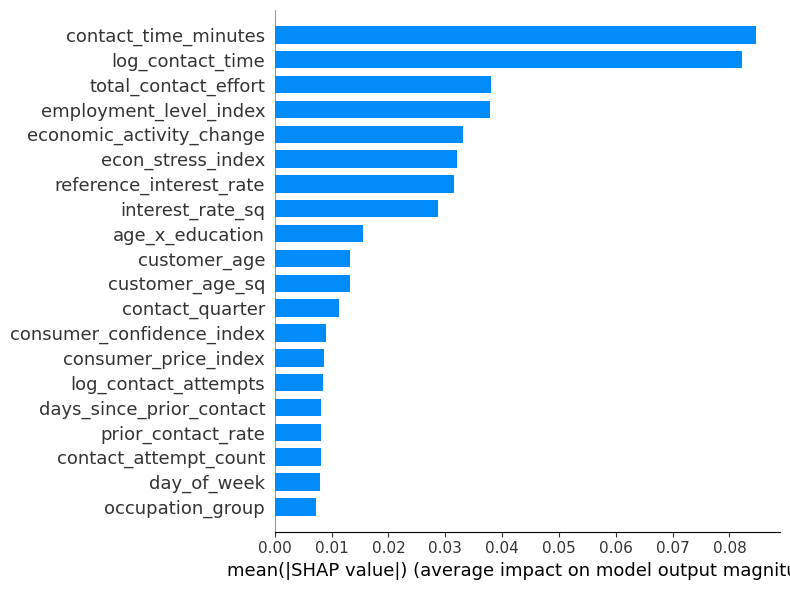

In [64]:
# Random Forest SHAP values on validation set
rf_explainer = shap.TreeExplainer(rf_model.named_steps['classifier'])
rf_shap_vals = rf_explainer.shap_values(
    rf_model.named_steps['preprocessor'].transform(X_val_fe)
)

# handle all shape cases: list, 3D array, or already 2D
if isinstance(rf_shap_vals, list):
    rf_shap_vals = rf_shap_vals[1]
elif rf_shap_vals.ndim == 3:
    rf_shap_vals = rf_shap_vals[:, :, 1]

# confirm 2D
assert rf_shap_vals.ndim == 2, f"Expected 2D SHAP array, got shape {rf_shap_vals.shape}"

# global feature importance bar plot
shap.summary_plot(
    rf_shap_vals,
    X_val_fe,
    feature_names=quant_vars + cat_vars,
    plot_type="bar",
    plot_size=(8, 6)
)

# top 10 features by mean absolute SHAP value
rf_shap_importance = pd.DataFrame({
    'feature': quant_vars + cat_vars,
    'shap_mean_abs': np.abs(rf_shap_vals).mean(axis=0)
}).sort_values('shap_mean_abs', ascending=False)

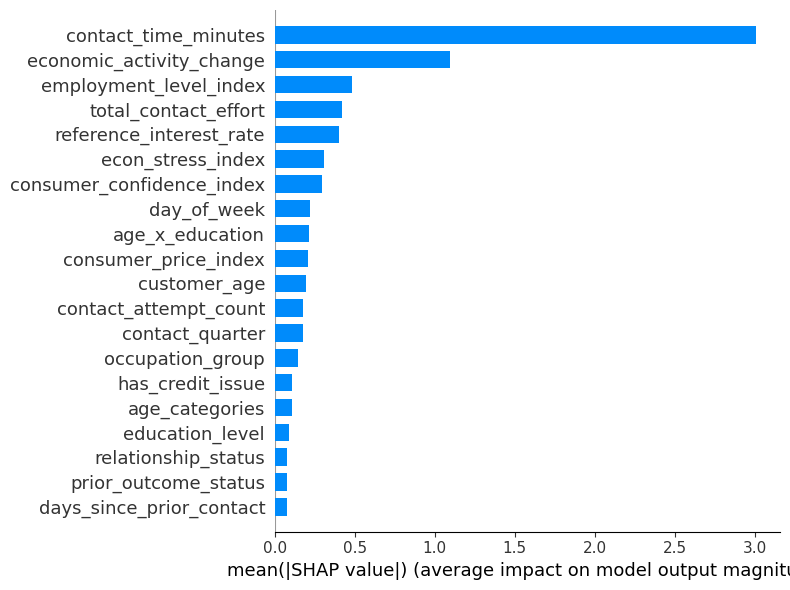

In [65]:
# XGBoost SHAP values on validation set
xgb_explainer = shap.TreeExplainer(xgb_model)
xgb_shap_vals = xgb_explainer.shap_values(X_val_fe)

# handle all shape cases: list, 3D array, or already 2D
if isinstance(xgb_shap_vals, list):
    xgb_shap_vals = xgb_shap_vals[1]
elif xgb_shap_vals.ndim == 3:
    xgb_shap_vals = xgb_shap_vals[:, :, 1]

# confirm 2D
assert xgb_shap_vals.ndim == 2, f"Expected 2D SHAP array, got shape {xgb_shap_vals.shape}"

# global feature importance bar plot
shap.summary_plot(
    xgb_shap_vals,
    X_val_fe,
    plot_type="bar",
    plot_size=(8, 6)
)

# top 10 features by mean absolute SHAP value
xgb_shap_importance = pd.DataFrame({
    'feature': X_val_fe.columns,
    'shap_mean_abs': np.abs(xgb_shap_vals).mean(axis=0)
}).sort_values('shap_mean_abs', ascending=False)

In [94]:
#Average rankings of feature importance, permutation importance, and SHAP values for Random Forest model
rf_feat_df = pd.DataFrame({
    "feature": quant_vars + cat_vars,  
    "feat_importance": rf_model.named_steps['classifier'].feature_importances_  
})

# rank feature importance and permutation importance results
rf_feat_df["rank_feat"] = rf_feat_df["feat_importance"].rank(ascending=False)
rf_perm_df["rank_perm"] = rf_perm_df["importance_mean"].rank(ascending=False)

# rank SHAP importance
rf_shap_importance["rank_shap"] = rf_shap_importance["shap_mean_abs"].rank(ascending=False)

# merge all three
rf_combined = (
    rf_feat_df
    .merge(rf_perm_df[["feature", "importance_mean", "rank_perm"]], on="feature")
    .merge(rf_shap_importance[["feature", "shap_mean_abs", "rank_shap"]], on="feature")
)

# average ranks across all three methods
rf_combined["rank_avg"] = (
    rf_combined["rank_feat"] + 
    rf_combined["rank_perm"] + 
    rf_combined["rank_shap"]
) / 3

# sort and display top 10 features
rf_combined = rf_combined.sort_values("rank_avg")
rf_top_features = rf_combined.head(10)
rf_top_features

,feature,feat_importance,rank_feat,importance_mean,rank_perm,shap_mean_abs,rank_shap,rank_avg
1,contact_time_minutes,0.184797,1.0,0.214143,2.0,0.084663,1.0,1.333333
12,log_contact_time,0.170881,2.0,0.215624,1.0,0.082134,2.0,1.666667
15,total_contact_effort,0.078831,3.0,0.099510,5.0,0.038006,3.0,3.666667
8,reference_interest_rate,0.066152,5.0,0.107754,3.0,0.031573,7.0,5.000000
14,econ_stress_index,0.067590,4.0,0.093151,7.0,0.032110,6.0,5.666667
9,employment_level_index,0.060009,7.0,0.096097,6.0,0.037932,4.0,5.666667
18,interest_rate_sq,0.060166,6.0,0.100765,4.0,0.028624,8.0,6.000000
5,economic_activity_change,0.036871,8.0,0.032713,8.0,0.033029,5.0,7.000000
0,customer_age,0.025618,11.0,0.002559,19.0,0.013294,10.0,13.333333
19,prior_contact_rate,0.015991,14.0,0.014217,11.0,0.008140,17.0,14.000000


In [95]:
#Average rankings of feature importance, permutation importance, and SHAP values for XGBoost model
xgb_feat_df = pd.DataFrame({
    "feature": X_train_fe.columns,
    "feat_importance": xgb_model.feature_importances_
})

# rank feature importance and permutation importance results
xgb_feat_df["rank_feat"] = xgb_feat_df["feat_importance"].rank(ascending=False)
xgb_perm_df["rank_perm"] = xgb_perm_df["importance_mean"].rank(ascending=False)

# rank SHAP importance
xgb_shap_importance["rank_shap"] = xgb_shap_importance["shap_mean_abs"].rank(ascending=False)

# merge all three
xgb_combined = (
    xgb_feat_df
    .merge(xgb_perm_df[["feature", "importance_mean", "rank_perm"]], on="feature")
    .merge(xgb_shap_importance[["feature", "shap_mean_abs", "rank_shap"]], on="feature")
)

# average ranks across all three methods
xgb_combined["rank_avg"] = (
    xgb_combined["rank_feat"] + 
    xgb_combined["rank_perm"] + 
    xgb_combined["rank_shap"]
) / 3

# sort and display top 10 features
xgb_combined = xgb_combined.sort_values("rank_avg")
xgb_top_features = xgb_combined.head(10)
xgb_top_features

,feature,feat_importance,rank_feat,importance_mean,rank_perm,shap_mean_abs,rank_shap,rank_avg
6,contact_time_minutes,0.080369,3.0,0.324504,1.0,3.009011,1.0,1.666667
15,employment_level_index,0.472032,1.0,0.047165,4.0,0.483295,3.0,2.666667
11,economic_activity_change,0.044592,5.0,0.065225,3.0,1.098589,2.0,3.333333
24,econ_stress_index,0.105280,2.0,0.025947,5.0,0.304513,6.0,4.333333
14,reference_interest_rate,0.022418,7.0,0.096416,2.0,0.401780,5.0,4.666667
13,consumer_confidence_index,0.076570,4.0,0.017322,6.0,0.292153,7.0,5.666667
25,total_contact_effort,0.008932,15.0,0.016684,8.0,0.422146,4.0,9.000000
12,consumer_price_index,0.020542,8.0,0.010755,9.0,0.210078,10.0,9.000000
5,day_of_week,0.009965,14.0,0.016956,7.0,0.220293,8.0,9.666667
23,contact_quarter,0.011273,12.0,0.009441,10.0,0.175807,13.0,11.666667


In [120]:
#define reduced feature set for Random Forest and XGBoost models

#Random forest reduced feature set (top 10 features)
X_train_rf_10 = X_train_fe[rf_top_features["feature"]]
X_val_rf_10 = X_val_fe[rf_top_features["feature"]]

#XGBoost reduced feature set (top 10 features)
X_train_xgb_10 = X_train_fe[xgb_top_features["feature"]]
X_val_xgb_10 = X_val_fe[xgb_top_features["feature"]]

In [116]:
# run baseline models with reduced feature set - Random Forest
rf_model_reduced = RandomForestClassifier(
    class_weight='balanced', 
    random_state=321, 
    n_jobs=-1
)

cv_scores_rf_reduced = cross_val_score(
    rf_model_reduced, X_train_rf_10, y_train_fe, cv=cv, scoring="f1", n_jobs=-1
)
print(cv_scores_rf_reduced)
print(cv_scores_rf_reduced.mean())
print(cv_scores_rf_reduced.std())

rf_model_reduced.fit(X_train_rf_10, y_train_fe)

y_pred = rf_model_reduced.predict(X_val_rf_10)
print("Random Forest F1 Score (Reduced feature set):", f1_score(y_val_fe, y_pred))
print(classification_report(y_val_fe, y_pred))

[0.55977757 0.55080722
 0.52376334 0.55028463
 0.55483871]
0.5478942931049067
0.012537456974301012
Random Forest F1 Score (Reduced feature set): 0.575689783743475
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      5847
           1       0.65      0.52      0.58       743

    accuracy                           0.91      6590
   macro avg       0.79      0.74      0.76      6590
weighted avg       0.91      0.91      0.91      6590



In [122]:
#run baseline models with reduced feature set - XGBoost
cv_scores_xgb_reduced = cross_val_score(xgb_model, X_train_xgb_10, y_train_fe, cv=cv, scoring="f1", n_jobs=-1)
print(cv_scores_xgb_reduced)
print(cv_scores_xgb_reduced.mean())
print(cv_scores_xgb_reduced.std())

xgb_model.fit(X_train_xgb_10, y_train_fe)

#evaluate final model performance on held out test set
y_pred = xgb_model.predict(X_val_xgb_10)
print("XGBoost Baseline F1 Score (Reduced feature set):", f1_score(y_val_fe, y_pred))
print("Classification Report:")
print(classification_report(y_val_fe, y_pred))

[0.60696517 0.60540541
 0.60669975 0.62303335
 0.60170524]
0.6087617846443827
0.007378585613381987
XGBoost Baseline F1 Score (Reduced feature set): 0.6439842209072978
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.89      0.94      5847
           1       0.51      0.88      0.64       743

    accuracy                           0.89      6590
   macro avg       0.75      0.89      0.79      6590
weighted avg       0.93      0.89      0.90      6590



**Quick insights:**
- Logistic regression performed similar to its performance on the full engineered feature set (F1 score on the held out test set of 0.581 vs. 0.58, respectively), but better compared to its performance with the baseline model (F1 score of 0.581 vs. 0.573, respectively)
- Random forest performed better with the reduced engineered feature set compared to the full engineered feature set (F1 score on the held out test set of 0.576 vs. 0.536, respectively) 
- XGBoost performed slightly worse with the reduced engineered feature set compared to the full engineered feature set (F1 score on the held out test set of 0.645 vs. 0.659, respectively)

Given these results, I will tune the following models:
- Logistic regression using LASSO
- Random forest using reduced feature set
- XGBoost using full feature set

In [124]:
#logistic regression model tuning
def objective_lr_lasso(trial):
    clf = LogisticRegression(
        l1_ratio=1.0,
        solver='saga',
        class_weight='balanced',
        max_iter=2000,
        random_state=321,
        C=trial.suggest_float('C', 1e-4, 10, log=True)
    )
    pipeline = Pipeline([
        ('preprocessor', preprocessor_lr),
        ('classifier', clf)
    ])
    return cross_val_score(pipeline, X_train_fe, y_train_fe, cv=cv, scoring='f1', n_jobs=-1).mean()

study_lr_lasso = optuna.create_study(direction='maximize')
study_lr_lasso.optimize(objective_lr_lasso, n_trials=50)
print("Best params:", study_lr_lasso.best_params)

# refit with best params
best_lr_lasso = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(
        l1_ratio=1.0,
        solver='saga',
        class_weight='balanced',
        max_iter=2000,
        random_state=321,
        C=study_lr_lasso.best_params['C']
    ))
])

best_lr_lasso.fit(X_train_fe, y_train_fe)
y_pred = best_lr_lasso.predict(X_val_fe)
print("Tuned LASSO LR F1 Score:", f1_score(y_val_fe, y_pred))
print(classification_report(y_val_fe, y_pred))

[I 2026-05-08 14:28:33,525] A new study created in memory with name: no-name-8f04e8ce-4cf7-40c2-887b-d5f4516a5077
[I 2026-05-08 14:28:37,334] Trial 0 finished with value: 0.5420026262295202 and parameters: {'C': 0.0010792338201258264}. Best is trial 0 with value: 0.5420026262295202.
[I 2026-05-08 14:28:40,512] Trial 1 finished with value: 0.5439455776653072 and parameters: {'C': 0.0025762069490374816}. Best is trial 1 with value: 0.5439455776653072.
[I 2026-05-08 14:28:41,780] Trial 2 finished with value: 0.5479034518776544 and parameters: {'C': 0.0003743209351968593}. Best is trial 2 with value: 0.5479034518776544.
[I 2026-05-08 14:28:46,634] Trial 3 finished with value: 0.5474427387207256 and parameters: {'C': 0.0059488609606054565}. Best is trial 2 with value: 0.5479034518776544.
[I 2026-05-08 14:28:46,829] Trial 4 finished with value: 0.04050460279577225 and parameters: {'C': 0.00012524240026346055}. Best is trial 2 with value: 0.5479034518776544.
[I 2026-05-08 14:28:50,183] Trial 

Best params: {'C': 6.063573330110476}
Tuned LASSO LR F1 Score: 0.5818022747156606
              precision    recall  f1-score   support

           0       0.98      0.85      0.91      5847
           1       0.43      0.90      0.58       743

    accuracy                           0.85      6590
   macro avg       0.71      0.87      0.75      6590
weighted avg       0.92      0.85      0.87      6590



/Users/donyabehroozi/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [125]:
#Random Forest model tuning
def objective_rf(trial):
    clf = RandomForestClassifier(
        n_estimators=trial.suggest_int('n_estimators', 100, 1000),
        max_depth=trial.suggest_int('max_depth', 5, 20),
        min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
        min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10),
        max_features=trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
        class_weight='balanced',
        random_state=321,
        n_jobs=-1
    )
    return cross_val_score(clf, X_train_rf_10, y_train_fe, cv=cv, scoring='f1', n_jobs=-1).mean()

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=50)

best_rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=321,
    n_jobs=-1,
    **study_rf.best_params
)
best_rf.fit(X_train_rf_10, y_train_fe)
y_pred_rf = best_rf.predict(X_val_rf_10)
print("Tuned Random Forest F1 Score (Reduced feature set):", f1_score(y_val_fe, y_pred_rf))
print(classification_report(y_val_fe, y_pred_rf))

[I 2026-05-08 14:41:29,646] A new study created in memory with name: no-name-c38c5f27-c4a6-4201-9612-bddee267f50d
[I 2026-05-08 14:41:32,725] Trial 0 finished with value: 0.5589971900120116 and parameters: {'n_estimators': 138, 'max_depth': 5, 'min_samples_split': 13, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 0 with value: 0.5589971900120116.
[I 2026-05-08 14:41:38,444] Trial 1 finished with value: 0.6191767061970348 and parameters: {'n_estimators': 512, 'max_depth': 10, 'min_samples_split': 15, 'min_samples_leaf': 3, 'max_features': 0.5}. Best is trial 1 with value: 0.6191767061970348.
[I 2026-05-08 14:41:44,840] Trial 2 finished with value: 0.6087390262365862 and parameters: {'n_estimators': 941, 'max_depth': 9, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.6191767061970348.
[I 2026-05-08 14:41:51,292] Trial 3 finished with value: 0.6032684417773901 and parameters: {'n_estimators': 1000, 'max_depth': 9, 'min

Tuned Random Forest F1 Score (Reduced feature set): 0.665140240412135
              precision    recall  f1-score   support

           0       0.97      0.93      0.95      5847
           1       0.58      0.78      0.67       743

    accuracy                           0.91      6590
   macro avg       0.77      0.85      0.81      6590
weighted avg       0.93      0.91      0.92      6590



In [126]:
#XGBoost model tuning
def objective_xgb(trial):
    clf = XGBClassifier(
        n_estimators=trial.suggest_int('n_estimators', 100, 1000),
        max_depth=trial.suggest_int('max_depth', 3, 10),
        learning_rate=trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        subsample=trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1.0),
        min_child_weight=trial.suggest_int('min_child_weight', 1, 10),
        gamma=trial.suggest_float('gamma', 0, 5),
        tree_method='hist',
        enable_categorical=True,
        scale_pos_weight=scale_pos_weight,
        random_state=321,
        n_jobs=-1,
        eval_metric='logloss'
    )
    return cross_val_score(clf, X_train_fe, y_train_fe, cv=cv, scoring='f1', n_jobs=-1).mean()

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=50)

best_xgb = XGBClassifier(
    tree_method='hist',
    enable_categorical=True,
    scale_pos_weight=scale_pos_weight,
    random_state=321,
    n_jobs=-1,
    eval_metric='logloss',
    **study_xgb.best_params
)
best_xgb.fit(X_train_fe, y_train_fe)
y_pred_xgb = best_xgb.predict(X_val_fe)
print("Tuned XGBoost F1 Score (Full engineered feature set):", f1_score(y_val_fe, y_pred_xgb))
print(classification_report(y_val_fe, y_pred_xgb))

[I 2026-05-08 14:46:53,597] A new study created in memory with name: no-name-104ee48e-fb45-4835-8d71-19b875f6d093
[I 2026-05-08 14:46:53,919] Trial 0 finished with value: 0.5987396685683463 and parameters: {'n_estimators': 125, 'max_depth': 3, 'learning_rate': 0.12491064337875227, 'subsample': 0.7779721351913463, 'colsample_bytree': 0.8613135088848625, 'min_child_weight': 3, 'gamma': 4.2190777523429315}. Best is trial 0 with value: 0.5987396685683463.
[I 2026-05-08 14:46:54,657] Trial 1 finished with value: 0.6336770887780705 and parameters: {'n_estimators': 683, 'max_depth': 9, 'learning_rate': 0.13603203538360636, 'subsample': 0.9327053028850696, 'colsample_bytree': 0.7526393385347797, 'min_child_weight': 1, 'gamma': 2.034945046816004}. Best is trial 1 with value: 0.6336770887780705.
[I 2026-05-08 14:46:55,325] Trial 2 finished with value: 0.6079732415803688 and parameters: {'n_estimators': 663, 'max_depth': 3, 'learning_rate': 0.040483917918006526, 'subsample': 0.6826646223979795, '

Tuned XGBoost F1 Score (Full engineered feature set): 0.6708595387840671
              precision    recall  f1-score   support

           0       0.98      0.91      0.94      5847
           1       0.55      0.86      0.67       743

    accuracy                           0.90      6590
   macro avg       0.77      0.89      0.81      6590
weighted avg       0.93      0.90      0.91      6590



**Quick insights:**
- The tuned logistic regression using LASSO performed better compared to the tuned logistic regression model using the full feature set (F1 score on held out test set of 0.582 vs. 0.572, respectively)
- The tuned random forest model using the reduced engineered feature set performed worse compared to the tuned random forest model using the full feature set (F1 score on held out test set of 0.665 vs. 0.673, respectively)
- The tuned XGBoost model using the full engineered feature set performed worse compared to the tuned XGBoost model using the full feature set without engineered features (F1 score on held out test set of 0.671 vs. 0.674, respectively)

## Ensemble model (probability model)

I will be using the full engineered feature sets for my ensemble models. Since XGBoost performed better in terms of F1 score on this feature set for class 1, I will optimize my tuning for this model to focus on maximizing F1 score for class 1. Random forest performed best in terms of F1 score on this feature set for class 1, so my tuning for this model will be optimized to maximize F1 score on this feature set for class 0.

In [128]:
#create custom F1 scores for tuning
f1_class1 = make_scorer(f1_score, pos_label=1)
f1_class0 = make_scorer(f1_score, pos_label=0)

In [130]:
#optimizing tuning for Random Forest model to maximize F1 score for class 0
def objective_rf_c0(trial):
    clf = RandomForestClassifier(
        n_estimators=trial.suggest_int('n_estimators', 100, 1000),
        max_depth=trial.suggest_int('max_depth', 5, 20),
        min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
        min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10),
        max_features=trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
        class_weight='balanced',
        random_state=321,
        n_jobs=-1
    )
    pipeline = Pipeline([('preprocessor', preprocessor_tree), ('classifier', clf)])
    return cross_val_score(pipeline, X_train_fe, y_train_fe, cv=cv, scoring=f1_class0, n_jobs=-1).mean()

study_rf_c0 = optuna.create_study(direction='maximize')
study_rf_c0.optimize(objective_rf_c0, n_trials=50)

best_rf_c0 = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('classifier', RandomForestClassifier(
        class_weight='balanced',
        random_state=321,
        n_jobs=-1,
        **study_rf_c0.best_params
    ))
])
best_rf_c0.fit(X_train_fe, y_train_fe)
y_pred_rf_c0 = best_rf_c0.predict(X_val_fe)
print("=== Random Forest Tuned for Class 0 ===")
print(f"Class 0 F1: {f1_score(y_val_fe, y_pred_rf_c0, pos_label=0):.4f}")
print(classification_report(y_val_fe, y_pred_rf_c0))

[I 2026-05-09 10:22:03,535] A new study created in memory with name: no-name-bc3b1b4c-4213-4d50-a25e-ff6675f11a58
[I 2026-05-09 10:22:16,470] Trial 0 finished with value: 0.9361742611273346 and parameters: {'n_estimators': 679, 'max_depth': 11, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 0.5}. Best is trial 0 with value: 0.9361742611273346.
[I 2026-05-09 10:22:19,897] Trial 1 finished with value: 0.9285107091461976 and parameters: {'n_estimators': 191, 'max_depth': 10, 'min_samples_split': 19, 'min_samples_leaf': 10, 'max_features': 0.5}. Best is trial 0 with value: 0.9361742611273346.
[I 2026-05-09 10:22:29,737] Trial 2 finished with value: 0.9066007262297481 and parameters: {'n_estimators': 750, 'max_depth': 6, 'min_samples_split': 18, 'min_samples_leaf': 2, 'max_features': 0.5}. Best is trial 0 with value: 0.9361742611273346.
[I 2026-05-09 10:22:31,755] Trial 3 finished with value: 0.933602394990098 and parameters: {'n_estimators': 272, 'max_depth': 20, 'min_samp

=== Random Forest Tuned for Class 0 ===
Class 0 F1: 0.9536
              precision    recall  f1-score   support

           0       0.96      0.95      0.95      5847
           1       0.63      0.68      0.65       743

    accuracy                           0.92      6590
   macro avg       0.79      0.82      0.80      6590
weighted avg       0.92      0.92      0.92      6590



In [129]:
#optimizing tuning for XGBoost model to maximize F1 score for class 1
def objective_xgb_c1(trial):
    clf = XGBClassifier(
        n_estimators=trial.suggest_int('n_estimators', 100, 1000),
        max_depth=trial.suggest_int('max_depth', 3, 10),
        learning_rate=trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        subsample=trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1.0),
        min_child_weight=trial.suggest_int('min_child_weight', 1, 10),
        gamma=trial.suggest_float('gamma', 0, 5),
        tree_method='hist',
        enable_categorical=True,
        scale_pos_weight=scale_pos_weight,
        random_state=321,
        n_jobs=-1,
        eval_metric='logloss'
    )
    return cross_val_score(clf, X_train_fe, y_train_fe, cv=cv, scoring=f1_class1, n_jobs=-1).mean()

study_xgb_c1 = optuna.create_study(direction='maximize')
study_xgb_c1.optimize(objective_xgb_c1, n_trials=50)

best_xgb_c1 = XGBClassifier(
    tree_method='hist',
    enable_categorical=True,
    scale_pos_weight=scale_pos_weight,
    random_state=321,
    n_jobs=-1,
    eval_metric='logloss',
    **study_xgb_c1.best_params
)
best_xgb_c1.fit(X_train_fe, y_train_fe)
y_pred_xgb_c1 = best_xgb_c1.predict(X_val_fe)
print("=== XGBoost Tuned and Optimized for Class 1 ===")
print(f"Class 1 F1: {f1_score(y_val_fe, y_pred_xgb_c1, pos_label=1):.4f}")
print(classification_report(y_val_fe, y_pred_xgb_c1))

[I 2026-05-09 10:19:00,338] A new study created in memory with name: no-name-efdce17c-6d62-4e4b-be6f-d81b7e855fdd
[I 2026-05-09 10:19:03,199] Trial 0 finished with value: 0.6279007158831621 and parameters: {'n_estimators': 289, 'max_depth': 8, 'learning_rate': 0.20109087542400653, 'subsample': 0.7742393334329648, 'colsample_bytree': 0.8807302944512003, 'min_child_weight': 7, 'gamma': 3.094630907469526}. Best is trial 0 with value: 0.6279007158831621.
[I 2026-05-09 10:19:04,615] Trial 1 finished with value: 0.6221637662610733 and parameters: {'n_estimators': 276, 'max_depth': 6, 'learning_rate': 0.1681922243217611, 'subsample': 0.5076867270160221, 'colsample_bytree': 0.7593553442139507, 'min_child_weight': 9, 'gamma': 0.6155800194862376}. Best is trial 0 with value: 0.6279007158831621.
[I 2026-05-09 10:19:06,433] Trial 2 finished with value: 0.6316722099253673 and parameters: {'n_estimators': 558, 'max_depth': 6, 'learning_rate': 0.03030583581493465, 'subsample': 0.7619701523781168, 'co

=== XGBoost Tuned and Optimized for Class 1 ===
Class 1 F1: 0.6702
              precision    recall  f1-score   support

           0       0.98      0.91      0.95      5847
           1       0.56      0.84      0.67       743

    accuracy                           0.91      6590
   macro avg       0.77      0.88      0.81      6590
weighted avg       0.93      0.91      0.91      6590



In [133]:
#Create ensemble model with the above tuned models and tune probability weights
print("Generating OOF predictions...")
rf_oof = cross_val_predict(best_rf_c0, X_train_fe, y_train_fe, cv=cv, method='predict_proba', n_jobs=-1)
xgb_oof = cross_val_predict(best_xgb_c1, X_train_fe, y_train_fe, cv=cv, method='predict_proba', n_jobs=-1)

# optimize ensemble weights with Optuna
def ensemble_objective(trial):
    w_xgb = trial.suggest_float('w_xgb', 0.0, 1.0)
    w_rf = trial.suggest_float('w_rf', 0.0, 1.0)
    total = w_xgb + w_rf

    blended = (w_xgb * xgb_oof + w_rf * rf_oof) / total
    preds = (blended[:, 1] >= 0.5).astype(int)
    return f1_score(y_train_fe, preds) 

ensemble_study = optuna.create_study(direction='maximize')
ensemble_study.optimize(ensemble_objective, n_trials=100)

# normalize best weights to sum to 1
raw = ensemble_study.best_params
total = sum(raw.values())
w_xgb = raw['w_xgb'] / total
w_rf = raw['w_rf'] / total

print(f'Best weights — XGB: {w_xgb:.3f}, RF: {w_rf:.3f}')
print(f'Best OOF F1: {ensemble_study.best_value:.4f}') 

xgb_val_probs = best_xgb_c1.predict_proba(X_val_fe)
rf_val_probs = best_rf_c0.predict_proba(X_val_fe)

# apply best weights to validation set
blended_val = w_xgb * xgb_val_probs + w_rf * rf_val_probs
ensemble_preds = (blended_val[:, 1] >= 0.5).astype(int)

print("Ensemble F1:", f1_score(y_val_fe, ensemble_preds))  
print("Classification Report:")
print(classification_report(y_val_fe, ensemble_preds))

Generating OOF predictions...


[I 2026-05-09 10:34:46,766] A new study created in memory with name: no-name-18fb27de-b351-486a-97a5-626bd7312e1a
[I 2026-05-09 10:34:46,771] Trial 0 finished with value: 0.6416982152514873 and parameters: {'w_xgb': 0.6838433033424745, 'w_rf': 0.08106007040344809}. Best is trial 0 with value: 0.6416982152514873.
[I 2026-05-09 10:34:46,776] Trial 1 finished with value: 0.6464135021097046 and parameters: {'w_xgb': 0.83221816080608, 'w_rf': 0.5439325799636313}. Best is trial 1 with value: 0.6464135021097046.
[I 2026-05-09 10:34:46,780] Trial 2 finished with value: 0.647613520963296 and parameters: {'w_xgb': 0.48580404459909166, 'w_rf': 0.6306436688198648}. Best is trial 2 with value: 0.647613520963296.
[I 2026-05-09 10:34:46,784] Trial 3 finished with value: 0.6483277834081367 and parameters: {'w_xgb': 0.5304627069627532, 'w_rf': 0.6622720444467569}. Best is trial 3 with value: 0.6483277834081367.
[I 2026-05-09 10:34:46,788] Trial 4 finished with value: 0.6463126843657817 and parameters: 

Best weights — XGB: 0.504, RF: 0.496
Best OOF F1: 0.6489
Ensemble F1: 0.6758304696449027
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95      5847
           1       0.59      0.79      0.68       743

    accuracy                           0.91      6590
   macro avg       0.78      0.86      0.81      6590
weighted avg       0.93      0.91      0.92      6590



In [135]:
#Create ensemble model with logistic regression meta-learner 
X_meta_train = np.column_stack([
    xgb_oof[:, 1],
    rf_oof[:, 1]
])

# get validation probabilities from each model
xgb_val_probs = best_xgb_c1.predict_proba(X_val_fe)
rf_val_probs = best_rf_c0.predict_proba(X_val_fe)

X_meta_val = np.column_stack([
    xgb_val_probs[:, 1],
    rf_val_probs[:, 1]
])

# fit meta learner on OOF predictions
meta_learner = LogisticRegression(
    class_weight='balanced',
    random_state=321,
    max_iter=1000
)
meta_learner.fit(X_meta_train, y_train_fe)

# evaluate on validation set
meta_preds = meta_learner.predict(X_meta_val)
print("Meta Learner F1:", f1_score(y_val_fe, meta_preds))
print("Classification Report:")
print(classification_report(y_val_fe, meta_preds))

# inspect meta learner weights
print("\nMeta learner coefficients:")
print(f"XGBoost weight: {meta_learner.coef_[0][0]:.4f}")
print(f"Random Forest weight: {meta_learner.coef_[0][1]:.4f}")

Meta Learner F1: 0.6653326663331666
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.90      0.94      5847
           1       0.53      0.90      0.67       743

    accuracy                           0.90      6590
   macro avg       0.76      0.90      0.80      6590
weighted avg       0.93      0.90      0.91      6590


Meta learner coefficients:
XGBoost weight: 1.8045
Random Forest weight: 6.0211


## Summary of Model Results

In [136]:
results = pd.DataFrame([
    # type, model, f1_score
    ('Baseline - Untouched Feature Set',  'Logistic Regression', 0.574),
    ('Baseline - Untouched Feature Set',  'Random Forest',       0.539),
    ('Baseline - Untouched Feature Set',  'XGBoost',             0.636),
    ('Baseline - Full FE Feature Set',    'Logistic Regression', 0.580),
    ('Baseline - Full FE Feature Set',    'Random Forest',       0.536),
    ('Baseline - Full FE Feature Set',    'XGBoost',             0.659),
    ('Baseline - Reduced FE Feature Set', 'Logistic Regression', 0.581),
    ('Baseline - Reduced FE Feature Set', 'Random Forest',       0.576),
    ('Baseline - Reduced FE Feature Set', 'XGBoost',             0.644),
    ('Tuned - Untouched Feature Set',     'Logistic Regression', 0.572),
    ('Tuned - Untouched Feature Set',     'Random Forest',       0.673),
    ('Tuned - Untouched Feature Set',     'XGBoost',             0.674),
    ('Tuned - Reduced FE Feature Set',    'Logistic Regression', 0.582),
    ('Tuned - Reduced FE Feature Set',    'Random Forest',       0.665),
    ('Tuned - Full FE Feature Set',       'XGBoost',             0.671),
    ('Ensemble',                          'RF + XGBoost (Prob Weighted)', 0.676),
    ('Ensemble',                          'RF + XGBoost + LR (Meta Learner)', 0.665),
], columns=['Type', 'Model', 'F1 Score'])

# rank by F1 score
results = results.sort_values('F1 Score', ascending=False).reset_index(drop=True)
results.index += 1  
results.index.name = 'Rank'

results

,Type,Model,F1 Score
Rank,,,
1,Ensemble,RF + XGBoost (Prob Weighted),0.676
2,Tuned - Untouched Feature Set,XGBoost,0.674
3,Tuned - Untouched Feature Set,Random Forest,0.673
4,Tuned - Full FE Feature Set,XGBoost,0.671
5,Ensemble,RF + XGBoost + LR (Meta Learner),0.665
6,Tuned - Reduced FE Feature Set,Random Forest,0.665
7,Baseline - Full FE Feature Set,XGBoost,0.659
8,Baseline - Reduced FE Feature Set,XGBoost,0.644
9,Baseline - Untouched Feature Set,XGBoost,0.636


## Use best model to make predictions on test data

In [141]:
#test data preprocessing
#transformations for skewed distributions
campaign_test['log_contact_time'] = np.log1p(campaign_test['contact_time_minutes'])
campaign_test['log_contact_attempts'] = np.log1p(campaign_test['contact_attempt_count'])

#binning of quantitative data
campaign_test['age_categories'] = pd.cut(
    campaign_test['customer_age'],
    bins=[0, 30, 40, 50, 60, 100],
    labels=['20s', '30s', '40s', '50s', '60+']
)

#binning of categorical data
#group occupation type into broader categories to avoid rare categories
campaign_test['occupation_group'] = campaign_test['occupation_type'].map(occupation_map)

#group education background into broader categories
campaign_test['education_level'] = campaign_test['education_background'].map(education_map)

#group last contact month into quarters
campaign_test['contact_quarter'] = campaign_test['last_contact_month'].map(month_quarter_map)


#interactions between features
#strong correlation between reference_interest_rate and employment_level_index
campaign_test['econ_stress_index'] = (campaign_test['reference_interest_rate'] * campaign_test['employment_level_index'])

#contact_time_minutes * contact_attempt_count = total engagement effort
campaign_test['total_contact_effort'] = (campaign_test['contact_time_minutes'] * campaign_test['contact_attempt_count'])

#age and education interaction
campaign_test['age_x_education'] = (
    campaign_test['customer_age'] * 
    campaign_test['education_level'].map({ 
        'higher': 3, 'secondary': 2, 'basic': 1, 'unknown': 0
    })
)

#polynomial features
campaign_test['customer_age_sq'] = campaign_test['customer_age'] ** 2

campaign_test['interest_rate_sq'] = campaign_test['reference_interest_rate'] ** 2

#other variable transformations/combinations
#prior contact rate relative to days since (contact intensity)
campaign_test['prior_contact_rate'] = (
    campaign_test['prior_contact_count'] / (campaign_test['days_since_prior_contact'] + 1)
)

#repeat customer who was also recently contacted
campaign_test['repeat_and_recent'] = (
    (campaign_test['is_repeat_customer'] == 1) & 
    (campaign_test['recent_contact_flag'] == 1)
).astype(int)

#convert to category dtype
for col in ['occupation_group', 'education_level', 'contact_quarter']:
    campaign_test[col] = campaign_test[col].astype('category')

for col in campaign_test.select_dtypes(include=['object']).columns:
    campaign_test[col] = campaign_test[col].astype('category')

#drop replaced columns
campaign_test = campaign_test.drop(['occupation_type', 'education_background', 'last_contact_month'], axis=1)

#define final test features
X_test_final = campaign_test.drop(['id'], axis=1)

#generate final predictions
xgb_test_probs = best_xgb_c1.predict_proba(X_test_final)
rf_test_probs  = best_rf_c0.predict_proba(X_test_final)

blended_test = w_xgb * xgb_test_probs + w_rf * rf_test_probs
final_preds = (blended_test[:, 1] >= 0.5).astype(int)

#save predictions
submission = pd.DataFrame({
    'id': campaign_test['id'],
    'accepted_offer': final_preds
})
submission.to_csv('midterm_predictions.csv', index=False)
submission.head()

<positron-console-cell-141>:60: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.


,id,accepted_offer
0,32884,0
1,3169,1
2,32206,1
3,9403,0
4,14020,0
